## Environment and GPU Verification

In [4]:
import sys
import torch
import cv2

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("OpenCV:", cv2.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs available:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())
    print("Using device: cuda")
else:
    print("Using device: cpu")

Python: c:\ProgramData\anaconda3\envs\Shri_Projects\python.exe
PyTorch: 2.5.1+cu121
OpenCV: 4.12.0
CUDA available: True
Number of GPUs available: 1
GPU: NVIDIA GeForce RTX 3060
Current device index: 0
Using device: cuda


## Dataset Paths and Configuration

In [9]:
from pathlib import Path

JSON_PATH = Path(r"D:\Research\CVD\CVD_Project\data_info.json")
ORIG_DIR = Path(r"D:\Research\CVD\CVD_Project\Fundus_CIMT_2903 Dataset")
GREEN_DIR = Path(r"D:\Research\CVD\CVD_Project\Fundus_green")
PROC_DIR = Path(r"D:\Research\CVD\CVD_Project\Fundus_green_CLAHE")
OUT_CSV = Path(r"D:\Research\CVD\CVD_Project\features_lbp_glcm_all.csv")

## Green Channel Extraction and Verification

In [10]:
import cv2

GREEN_DIR.mkdir(parents=True, exist_ok=True)

VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

ok = 0
skipped = 0

orig_files = sorted([
    p for p in ORIG_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in VALID_EXTS
])

for img_path in orig_files:
    img = cv2.imread(str(img_path))

    if img is None:
        print(f"Skipping unreadable file: {img_path.name}")
        skipped += 1
        continue

    # Extract green channel from BGR image
    green = img[:, :, 1]

    cv2.imwrite(
        str(GREEN_DIR / img_path.name),
        green
    )

    ok += 1

print(f"Saved {ok} green-channel images; skipped {skipped}.")


# Verification
green_files = sorted([
    p for p in GREEN_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in VALID_EXTS
])

orig_names = {p.name for p in orig_files}
green_names = {p.name for p in green_files}

missing_in_green = sorted(orig_names - green_names)
extra_in_green = sorted(green_names - orig_names)

print("\nVerification:")
print(f"Original images:      {len(orig_files)}")
print(f"Green-channel images: {len(green_files)}")
print(f"Missing images:       {len(missing_in_green)}")
print(f"Extra images:         {len(extra_in_green)}")

if not missing_in_green and not extra_in_green:
    print("Green-channel extraction verified successfully.")
else:
    if missing_in_green:
        print("Missing:", missing_in_green[:10])

    if extra_in_green:
        print("Extra:", extra_in_green[:10])

Saved 5806 green-channel images; skipped 0.

Verification:
Original images:      5806
Green-channel images: 5806
Missing images:       0
Extra images:         0
Green-channel extraction verified successfully.


## Original and Green Channel Image Visualization

Selected normal: 3 | thickened: 3


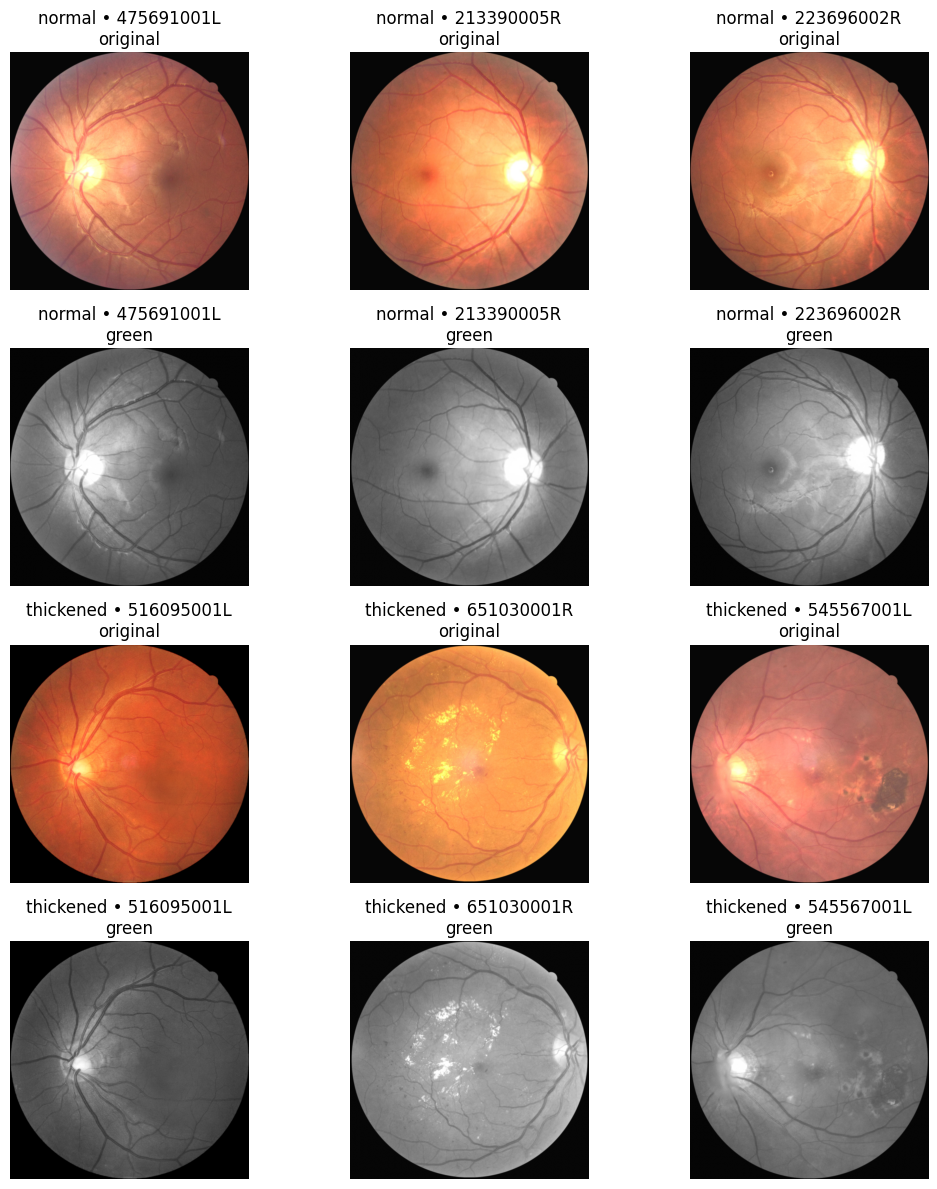

In [11]:
import os, json, random, cv2
import pandas as pd
import matplotlib.pyplot as plt

K_PER_CLASS = 3

random.seed(42)

# Read JSON: dict(patient_id -> {label, left_eye, right_eye, ...})
with open(JSON_PATH, "r") as f:
    data = json.load(f)
assert isinstance(data, dict), "data_info.json should be a dict of patient_id -> info"

# Build rows: one per available eye file
rows = []
for pid, info in data.items():
    label = int(info.get("label", 0))
    le = info.get("left_eye")
    re = info.get("right_eye")
    if le: rows.append({"patient_id": str(pid), "eye": "L", "filename": os.path.basename(le), "label": label})
    if re: rows.append({"patient_id": str(pid), "eye": "R", "filename": os.path.basename(re), "label": label})

df = pd.DataFrame(rows)
if df.empty:
    raise ValueError("No images parsed from JSON (check keys 'label', 'left_eye', 'right_eye').")

df["exists"] = df["filename"].apply(lambda n: (ORIG_DIR / n).exists())
df = df[df["exists"]].drop(columns=["exists"])
if df.empty:
    raise ValueError("None of the JSON-listed filenames exist in ORIG_DIR.")

df_normal    = df[df["label"] == 0]
df_thickened = df[df["label"] == 1]

take_normal    = df_normal.sample(min(K_PER_CLASS, len(df_normal)), random_state=42)
take_thickened = df_thickened.sample(min(K_PER_CLASS, len(df_thickened)), random_state=42)

print(f"Selected normal: {len(take_normal)} | thickened: {len(take_thickened)}")

def show_pairs(subdf, row_offset, title_prefix, cols):
    for i, row in enumerate(subdf.itertuples(index=False)):
        fname = row.filename

        # Original
        img = cv2.imread(str(ORIG_DIR / fname))[:,:,::-1]
        ax = plt.subplot(4, cols, row_offset*cols + i + 1)
        ax.imshow(img); ax.axis("off"); ax.set_title(f"{title_prefix} • {row.patient_id}{row.eye}\noriginal")

        # Green channel
        gp = GREEN_DIR / fname
        if gp.exists():
            gimg = cv2.imread(str(gp), cv2.IMREAD_GRAYSCALE)
        else:
            gimg = cv2.imread(str(ORIG_DIR / fname), cv2.IMREAD_COLOR)[:,:,1]

        ax = plt.subplot(4, cols, (row_offset+1)*cols + i + 1)
        ax.imshow(gimg, cmap="gray"); ax.axis("off"); ax.set_title(f"{title_prefix} • {row.patient_id}{row.eye}\ngreen")

cols = max(len(take_normal), len(take_thickened))
plt.figure(figsize=(3.6*cols, 12))

show_pairs(take_normal.reset_index(drop=True), 0, "normal", cols)
show_pairs(take_thickened.reset_index(drop=True), 2, "thickened", cols)

plt.tight_layout()
plt.show()

## CLAHE and Min-Max

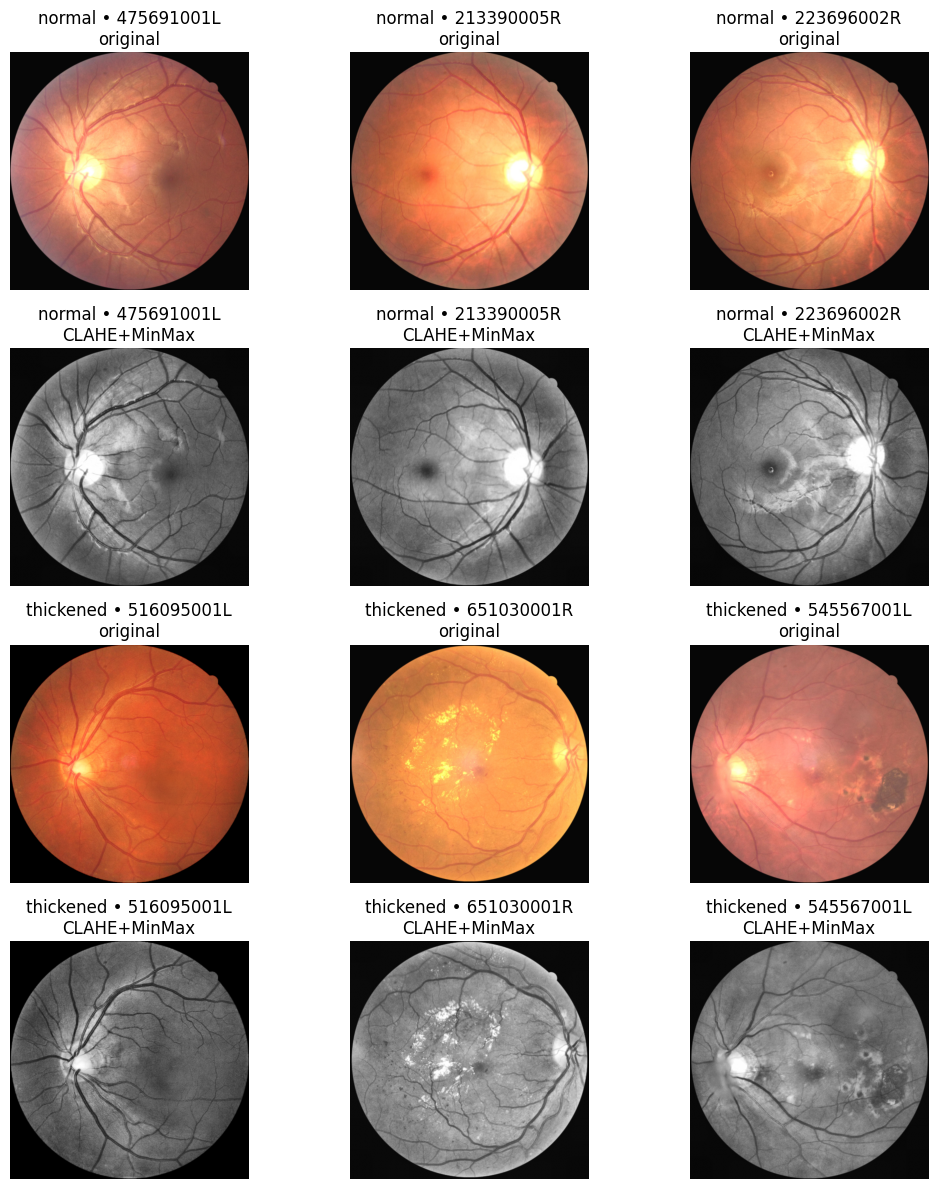

✅ Saved processed images to: D:\Research\CVD\CVD_Project\Fundus_green_CLAHE


In [12]:
import os, json, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

K_PER_CLASS = 3
CLAHE_CLIP = 2.0
CLAHE_TILE = (8, 8)
EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

PROC_DIR.mkdir(parents=True, exist_ok=True)

def _rows_from_json(json_path, orig_dir):
    with open(json_path, "r") as f:
        data = json.load(f)

    rows = []
    for pid, info in data.items():
        label = int(info.get("label", 0))
        for eye_key, eye_tag in [("left_eye", "L"), ("right_eye", "R")]:
            fn = info.get(eye_key)
            if fn:
                fname = os.path.basename(fn)
                if (orig_dir / fname).exists():
                    rows.append({"patient_id": str(pid), "eye": eye_tag, "filename": fname, "label": label})

    return pd.DataFrame(rows)

def green_clahe_minmax_from_bgr(bgr, clahe_obj):
    g = bgr[:, :, 1]
    g = clahe_obj.apply(g)
    g = g.astype(np.float32)
    g = (g - g.min()) / (g.max() - g.min() + 1e-6)
    return (g * 255.0).round().astype(np.uint8)

clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)

# Visualize selected samples
df = _rows_from_json(JSON_PATH, ORIG_DIR)
assert not df.empty, "No images found via JSON in ORIG_DIR."

df_n = df[df["label"] == 0]
df_t = df[df["label"] == 1]

take_n = df_n.sample(min(K_PER_CLASS, len(df_n)), random_state=42)
take_t = df_t.sample(min(K_PER_CLASS, len(df_t)), random_state=42)

pairs = [("normal", take_n), ("thickened", take_t)]
cols = max(len(take_n), len(take_t)) if len(take_n) or len(take_t) else 1

plt.figure(figsize=(3.6*cols, 12))

row_offset = 0
for title_prefix, subdf in pairs:
    subdf = subdf.reset_index(drop=True)

    for i, row in enumerate(subdf.itertuples(index=False)):
        bgr = cv2.imread(str(ORIG_DIR / row.filename))
        if bgr is None:
            continue

        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        ax = plt.subplot(4, cols, row_offset*cols + i + 1)
        ax.imshow(rgb); ax.axis("off"); ax.set_title(f"{title_prefix} • {row.patient_id}{row.eye}\noriginal")

        g8 = green_clahe_minmax_from_bgr(bgr, clahe)
        ax = plt.subplot(4, cols, (row_offset+1)*cols + i + 1)
        ax.imshow(g8, cmap="gray"); ax.axis("off"); ax.set_title(f"{title_prefix} • {row.patient_id}{row.eye}\nCLAHE+MinMax")

    row_offset += 2

plt.tight_layout()
plt.show()

# Process and save the complete dataset
in_files = sorted([p for p in ORIG_DIR.rglob("*") if p.suffix.lower() in EXTS])

for src in in_files:
    rel = src.relative_to(ORIG_DIR)
    dst = PROC_DIR / rel
    dst.parent.mkdir(parents=True, exist_ok=True)

    bgr = cv2.imread(str(src))
    if bgr is None:
        continue

    g8 = green_clahe_minmax_from_bgr(bgr, clahe)
    cv2.imwrite(str(dst), g8)

print(f"✅ Saved processed images to: {PROC_DIR}")


## LBP and GLCM Feature Extraction

In [13]:
import os, json, cv2, numpy as np, pandas as pd
from math import pi
from skimage.feature import local_binary_pattern, graycomatrix
from skimage.morphology import binary_opening, binary_closing, disk

# Simple mask from processed image (already uint8 [0..255])
def make_mask_from_processed(g8: np.ndarray):
    g = g8.astype(np.float32) / 255.0
    blur = cv2.GaussianBlur(g, (31, 31), 0)
    mask = (blur > 0.05).astype(np.uint8)
    mask = binary_opening(mask, disk(3)).astype(np.uint8)
    mask = binary_closing(mask, disk(5)).astype(np.uint8)
    return g, mask

# LBP (uniform histogram)
def feats_lbp(g_norm: np.ndarray, mask=None, P=16, R=2):
    lbp = local_binary_pattern((g_norm * 255).astype(np.uint8), P, R, method="uniform")
    n_bins = P + 2
    vals = lbp[mask.astype(bool)] if mask is not None else lbp.ravel()
    hist, _ = np.histogram(vals, bins=n_bins, range=(0, n_bins), density=True)
    return {f"lbp_u{P}_r{R}_{i}": float(hist[i]) for i in range(n_bins)}

# GLCM (14 Haralick features, mean/std across dists×angles)
def feats_glcm(g_norm: np.ndarray, mask=None, levels=64):
    I = (g_norm * (levels - 1)).round().astype(np.uint8)
    if mask is not None:
        I = I.copy()
        I[~mask.astype(bool)] = 0

    dists = [1, 2]
    angles = [0, pi/4, pi/2, 3*pi/4]
    P = graycomatrix(I, distances=dists, angles=angles, levels=levels, symmetric=True, normed=True)

    def _safe_log2(x):
        x = np.asarray(x, dtype=np.float64)
        with np.errstate(divide='ignore', invalid='ignore'):
            return np.where(x > 0, np.log2(x), 0.0)

    def _haralick_from_P(p):
        p = p.astype(np.float64, copy=False)
        px = p.sum(axis=1); py = p.sum(axis=0)
        L = p.shape[0]
        idx = np.arange(L)

        ux = (idx * px).sum()
        uy = (idx * py).sum()
        sx = np.sqrt(((idx - ux) ** 2 * px).sum() + 1e-12)
        sy = np.sqrt(((idx - uy) ** 2 * py).sum() + 1e-12)

        asm = (p ** 2).sum()
        i = idx[:, None]; j = idx[None, :]
        contrast = (((i - j) ** 2) * p).sum()
        correlation = (((i - ux) * (j - uy) * p).sum()) / (sx * sy) if (sx > 0 and sy > 0) else 1.0
        variance = (((i - ux) ** 2) * p).sum()
        idm = (p / (1.0 + (i - j) ** 2)).sum()

        p_sum = np.zeros(2 * L - 1)
        p_diff = np.zeros(L)
        for ii in range(L):
            for jj in range(L):
                val = p[ii, jj]
                p_sum[ii + jj] += val
                p_diff[abs(ii - jj)] += val

        HXY = -(p * _safe_log2(p)).sum()
        HX = -(px * _safe_log2(px)).sum()
        HY = -(py * _safe_log2(py)).sum()
        pxpy = px[:, None] * py[None, :]
        HXY1 = -(p * _safe_log2(pxpy)).sum()
        HXY2 = -(pxpy * _safe_log2(pxpy)).sum()

        k = np.arange(2 * L - 1)
        sum_avg = (k * p_sum).sum()
        sum_entropy = -(p_sum * _safe_log2(p_sum)).sum()
        sum_var = ((k - sum_entropy) ** 2 * p_sum).sum()
        entropy = HXY
        d = np.arange(L)
        dm = (d * p_diff).sum()
        diff_var = (((d - dm) ** 2) * p_diff).sum()
        diff_entropy = -(p_diff * _safe_log2(p_diff)).sum()
        imc1 = (HXY - HXY1) / max(HX, HY) if max(HX, HY) > 0 else 0.0
        imc2 = np.sqrt(max(0.0, 1.0 - np.exp(-2.0 * (HXY2 - HXY))))

        Q = np.zeros((L, L))
        nz_px = np.where(px == 0, 1, px)
        nz_py = np.where(py == 0, 1, py)
        for ii in range(L):
            for jj in range(L):
                num = (p[ii, :] * p[jj, :] / nz_py).sum()
                Q[ii, jj] = num / nz_px[ii]

        try:
            eig = np.linalg.eigvals(Q)
            eig = np.sort(np.real(eig))
            mcc = np.sqrt(max(0.0, eig[-2])) if len(eig) >= 2 else 0.0
        except np.linalg.LinAlgError:
            mcc = 0.0

        return {"asm": asm, "contrast": contrast, "correlation": correlation, "variance": variance, "idm": idm,
                "sum_avg": sum_avg, "sum_var": sum_var, "sum_entropy": sum_entropy, "entropy": entropy,
                "diff_var": diff_var, "diff_entropy": diff_entropy, "imc1": imc1, "imc2": imc2, "mcc": mcc}

    feats = []
    for di in range(len(dists)):
        for ai in range(len(angles)):
            feats.append(_haralick_from_P(P[:, :, di, ai]))

    agg = {}
    for k in feats[0].keys():
        vals = np.array([f[k] for f in feats])
        agg[f"glcm_{k}_mean"] = float(vals.mean())
        agg[f"glcm_{k}_std"] = float(vals.std())
    return agg

# Extract features only if CSV does not already exist
if os.path.exists(OUT_CSV):
    print(f"Feature CSV already exists. Skipping extraction: {OUT_CSV}")
    df = pd.read_csv(OUT_CSV)

else:
    with open(JSON_PATH, "r", encoding="utf-8") as f:
        data = json.load(f)
    assert isinstance(data, dict), "data_info.json must be dict: patient_id -> {...}"

    rows, missing_proc = [], []

    for pid, info in data.items():
        label = int(info.get("label", 0))
        for eye_key, eye_tag in (("left_eye", "L"), ("right_eye", "R")):
            fn = info.get(eye_key)
            if not fn:
                continue

            fname = os.path.basename(fn)
            p_proc = PROC_DIR / fname

            if p_proc.suffix.lower() not in EXTS or not p_proc.exists():
                missing_proc.append(fname)
                continue

            g8 = cv2.imread(str(p_proc), cv2.IMREAD_GRAYSCALE)
            if g8 is None:
                missing_proc.append(fname)
                continue

            g_norm, mask = make_mask_from_processed(g8)
            d_lbp = feats_lbp(g_norm, mask, P=16, R=2)
            d_glcm = feats_glcm(g_norm, mask, levels=64)

            row = {"patient_id": str(pid), "eye": eye_tag, "filename": fname, "label": label}
            row.update(d_lbp)
            row.update(d_glcm)
            rows.append(row)

    df = pd.DataFrame(rows).fillna(0.0)
    print("Feature matrix shape:", df.shape)
    df.to_csv(OUT_CSV, index=False)
    print("Saved CSV:", OUT_CSV)

    if missing_proc:
        miss = sorted(set(missing_proc))
        print(f"WARNING: {len(miss)} processed files missing or unreadable.")
        print("Examples:", miss[:10])

Feature CSV already exists. Skipping extraction: D:\Research\CVD\CVD_Project\features_lbp_glcm_all.csv


## Deep Learning Setup and Evaluation Metrics

In [14]:
import os, re, json, random, time, math
import numpy as np
import pandas as pd
from pathlib import Path

import cv2
import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
import timm
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, matthews_corrcoef, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

# Reproducibility and GPU setup
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "|", torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU")
assert device.type == "cuda", "CUDA not available. Install CUDA PyTorch and try again."

# Metrics helper
def metrics_from_logits(logits_cat, labels_np):
    y_true = labels_np
    y_prob = torch.softmax(logits_cat, dim=1)[:,1].detach().cpu().numpy()
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    auc = roc_auc_score(y_true, y_prob)
    mcc = matthews_corrcoef(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred).tolist()

    return {"acc":acc, "prec":pr, "rec":rc, "f1":f1, "auc":auc, "mcc":mcc, "cm":cm}

C:\Users\Shri\AppData\Roaming\Python\Python311\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
C:\Users\Shri\AppData\Roaming\Python\Python311\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because a

Device: cuda | NVIDIA GeForce RTX 3060


## Deep Learning Configuration and Tensor Caching

In [18]:
CACHE_DIR = Path("Fundus_green_CLAHE_pt")
SPLIT_DIR = Path("CVD_split")

CACHE_DIR.mkdir(exist_ok=True)
SPLIT_DIR.mkdir(exist_ok=True)

IMG_SIZE = 224
NUM_CLASSES = 2

MEAN = torch.tensor([0.5, 0.5, 0.5], dtype=torch.float32, device=device)
STD = torch.tensor([0.25, 0.25, 0.25], dtype=torch.float32, device=device)

def cache_one(in_path: Path):
    out_path = CACHE_DIR / f"{in_path.stem}.pt"
    if out_path.exists():
        return True

    g = cv2.imread(str(in_path), cv2.IMREAD_GRAYSCALE)
    if g is None:
        return False

    g = cv2.resize(g, (IMG_SIZE, IMG_SIZE), cv2.INTER_AREA)
    t = torch.from_numpy(g).to(torch.uint8).unsqueeze(0)
    torch.save(t, out_path)
    return True

made = 0
for p in PROC_DIR.rglob("*"):
    if p.suffix.lower() in EXTS:
        if not (CACHE_DIR / f"{p.stem}.pt").exists():
            if cache_one(p):
                made += 1

print(f"[CACHE] new tensors made: {made} | total cached: {len(list(CACHE_DIR.glob('*.pt')))}")

[CACHE] new tensors made: 0 | total cached: 5806


## Patient-Wise Stratified Train–Validation–Test Split

In [21]:
from sklearn.model_selection import StratifiedGroupKFold

train_csv = SPLIT_DIR / "train.csv"
val_csv = SPLIT_DIR / "val.csv"
test_csv = SPLIT_DIR / "test.csv"

# Load existing splits if already created
if train_csv.exists() and val_csv.exists() and test_csv.exists():
    tr_df = pd.read_csv(train_csv)
    va_df = pd.read_csv(val_csv)
    te_df = pd.read_csv(test_csv)
    print("Existing patient-wise splits loaded.")

else:
    # Load patient metadata
    with open(JSON_PATH, "r", encoding="utf-8") as f:
        data = json.load(f)

    rows = []

    for patient_id, info in data.items():
        label = int(info["label"])

        for eye_key in ("left_eye", "right_eye"):
            fn = info.get(eye_key)
            if not fn:
                continue

            filename = os.path.basename(fn)
            stem = Path(filename).stem
            pt_path = CACHE_DIR / f"{stem}.pt"

            if not pt_path.exists():
                raise FileNotFoundError(f"Cached tensor not found: {pt_path}")

            rows.append({
                "patient": str(patient_id),
                "filename": filename,
                "label": label,
                "filepath": str(pt_path)
            })

    meta = pd.DataFrame(rows)

    # One row per patient
    pat_tab = meta.groupby("patient").agg(
        label=("label", "max"),
        n=("filename", "count")
    ).reset_index()

    # 15% test
    y_all = pat_tab["label"].to_numpy()
    g_all = pat_tab["patient"].to_numpy()

    sgkf_test = StratifiedGroupKFold(n_splits=int(1/0.15), shuffle=True, random_state=SEED)
    _, test_idx = next(sgkf_test.split(np.zeros_like(y_all), y_all, groups=g_all))

    mask_test = np.zeros(len(pat_tab), dtype=bool)
    mask_test[test_idx] = True

    pat_test = pat_tab[mask_test].reset_index(drop=True)
    pat_dev = pat_tab[~mask_test].reset_index(drop=True)

    # 15% validation
    val_target = int(round(0.15 * len(pat_tab)))

    y_dev = pat_dev["label"].to_numpy()
    g_dev = pat_dev["patient"].to_numpy()

    sgkf_val = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

    best_val_idx = None
    best_diff = float("inf")

    for _, val_idx in sgkf_val.split(np.zeros_like(y_dev), y_dev, groups=g_dev):
        diff = abs(len(val_idx) - val_target)
        if diff < best_diff:
            best_diff = diff
            best_val_idx = val_idx

    mask_val = np.zeros(len(pat_dev), dtype=bool)
    mask_val[best_val_idx] = True

    pat_val = pat_dev[mask_val].reset_index(drop=True)
    pat_trn = pat_dev[~mask_val].reset_index(drop=True)

    # Map patient splits back to images
    def rows_for(patients):
        return meta.loc[
            meta["patient"].isin(patients["patient"]),
            ["filepath", "label", "filename"]
        ].reset_index(drop=True)

    tr_df = rows_for(pat_trn)
    va_df = rows_for(pat_val)
    te_df = rows_for(pat_test)

    tr_df.to_csv(train_csv, index=False)
    va_df.to_csv(val_csv, index=False)
    te_df.to_csv(test_csv, index=False)

    print(f"[patients] total={len(pat_tab)} | train={len(pat_trn)} val={len(pat_val)} test={len(pat_test)}")
    print("Patient-wise splits created and saved.")

def _counts(df):
    return {"n":len(df), "labels":df["label"].value_counts().to_dict()}

print("train:", _counts(tr_df))
print("val:  ", _counts(va_df))
print("test: ", _counts(te_df))

Existing patient-wise splits loaded.
train: {'n': 1936, 'labels': {1: 1369, 0: 567}}
val:   {'n': 483, 'labels': {1: 359, 0: 124}}
test:  {'n': 484, 'labels': {1: 326, 0: 158}}


## Load Train, Validation, and Test Tensors to GPU

In [22]:
def _load_csv(csv_path):
    df = pd.read_csv(csv_path)
    return df["filepath"].tolist(), df["label"].astype(int).to_numpy(), df["filename"].astype(str).tolist()

def _stack_to_gpu(paths):
    xs = []
    for p in paths:
        t = torch.load(p, map_location="cpu")
        if t.ndim == 2: t = t.unsqueeze(0)
        t = t.to(device, non_blocking=True).float().div_(255.0)
        if t.size(0) == 1: t = t.repeat(3, 1, 1)
        t = (t - MEAN[:, None, None]) / STD[:, None, None]
        xs.append(t.half())
    return torch.stack(xs, dim=0)

tr_paths, tr_labels, tr_names = _load_csv(SPLIT_DIR/"train.csv")
va_paths, va_labels, va_names = _load_csv(SPLIT_DIR/"val.csv")
te_paths, te_labels, te_names = _load_csv(SPLIT_DIR/"test.csv")

print("Loading tensors to GPU...")

Xtr = _stack_to_gpu(tr_paths); Ytr = torch.from_numpy(tr_labels).to(device).long()
Xva = _stack_to_gpu(va_paths); Yva = torch.from_numpy(va_labels).to(device).long()
Xte = _stack_to_gpu(te_paths); Yte = torch.from_numpy(te_labels).to(device).long()

if device.type == "cuda":
    print("GPU tensors:", Xtr.shape, Xva.shape, Xte.shape, "| mem≈", f"{torch.cuda.memory_allocated()/1e9:.2f} GB")
else:
    print("Tensors on CPU:", Xtr.shape, Xva.shape, Xte.shape)

Loading tensors to GPU...


C:\Users\Shri\AppData\Local\Temp\ipykernel_2208\39615797.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  t = torch.load(p, map_location="cpu")


GPU tensors: torch.Size([1936, 3, 224, 224]) torch.Size([483, 3, 224, 224]) torch.Size([484, 3, 224, 224]) | mem≈ 0.87 GB


## DenseNet-121 Training

In [ ]:
# Training configuration
LR_RUN = 1e-4
EPOCHS_RUN = 40
PATIENCE_RUN = 8
WEIGHT_DECAY = 1e-4
STOP_METRIC = "f1"
AUG_P = 0.5

OUT_DIR = Path("runs_densenet_lr1e4_ep40_weightedCE")
OUT_DIR.mkdir(exist_ok=True, parents=True)
Path("checkpoints").mkdir(exist_ok=True)

# Model
model = timm.create_model("densenet121", pretrained=True, num_classes=NUM_CLASSES).to(device)

# Weighted cross-entropy loss
class_counts = torch.bincount(Ytr.detach().cpu(), minlength=NUM_CLASSES).float()
class_weights = class_counts.sum() / (NUM_CLASSES * class_counts)
class_weights = class_weights.to(device)

print("Class counts:", class_counts.tolist())
print("Class weights:", class_weights.detach().cpu().tolist())

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR_RUN, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

_device_is_cuda = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda") if _device_is_cuda else None

def amp_ctx():
    return torch.amp.autocast("cuda") if _device_is_cuda else nullcontext()

# GPU augmentation
def augment_gpu(x):
    if not model.training:
        return x

    if torch.rand(1, device=x.device) < AUG_P:
        x = torch.flip(x, dims=[3])

    b = (torch.rand(x.size(0), 1, 1, 1, device=x.device) - 0.5) * 0.10
    c = 1.0 + (torch.rand(x.size(0), 1, 1, 1, device=x.device) - 0.5) * 0.10
    x = (x * c + b).clamp_(-4, 4)
    return x

# One epoch
def _epoch_gpu_full(X, Y, train=True, batch=BATCH_SIZE):
    model.train(train)
    N = X.size(0)
    order = torch.randperm(N, device=device) if train else torch.arange(N, device=device)

    total_loss = 0.0
    logits_all = []

    for i in range(0, N, batch):
        idx = order[i:i+batch]
        xb, yb = X[idx], Y[idx]

        if train:
            xb = augment_gpu(xb)

        with amp_ctx():
            out = model(xb)
            loss = criterion(out, yb)

        if train:
            optimizer.zero_grad(set_to_none=True)

            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * yb.size(0)
        logits_all.append(out.detach())

    logits_cat = torch.cat(logits_all, dim=0)
    mets = metrics_from_logits(logits_cat, Y.detach().cpu().numpy())
    mets["loss"] = total_loss / N
    return mets

# Training loop
best_score = -1.0
best_state = None
best_epoch = -1
best_val = None
best_train = None
pat = PATIENCE_RUN
history = []

for ep in range(1, EPOCHS_RUN + 1):
    trM = _epoch_gpu_full(Xtr, Ytr, train=True, batch=BATCH_SIZE)
    vaM = _epoch_gpu_full(Xva, Yva, train=False, batch=BATCH_SIZE)

    current_lr = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": ep, "lr": current_lr,
        "tr_loss": trM["loss"], "tr_acc": trM["acc"], "tr_prec": trM["prec"],
        "tr_rec": trM["rec"], "tr_f1": trM["f1"], "tr_auc": trM["auc"], "tr_mcc": trM["mcc"],
        "va_loss": vaM["loss"], "va_acc": vaM["acc"], "va_prec": vaM["prec"],
        "va_rec": vaM["rec"], "va_f1": vaM["f1"], "va_auc": vaM["auc"], "va_mcc": vaM["mcc"]
    }
    history.append(row)

    print(
        f"[Ep {ep:02d}] LR={current_lr:.2e} | "
        f"TR L={trM['loss']:.3f} A={trM['acc']:.3f} F1={trM['f1']:.3f} AUC={trM['auc']:.3f} | "
        f"VA L={vaM['loss']:.3f} A={vaM['acc']:.3f} F1={vaM['f1']:.3f} AUC={vaM['auc']:.3f}"
    )

    scheduler.step(vaM[STOP_METRIC])
    score = vaM[STOP_METRIC]

    if score > best_score:
        best_score = score
        best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
        best_epoch = ep
        best_val = vaM.copy()
        best_train = trM.copy()
        pat = PATIENCE_RUN
    else:
        pat -= 1
        if pat <= 0:
            print("Early stop.")
            break

# Restore and save best checkpoint
ckpt_path = Path("checkpoints/densenet_best_lr1e4_ep40_weightedCE.pth")

if best_state is not None:
    torch.save(best_state, ckpt_path)
    model.load_state_dict(best_state, strict=True)

# Save training history
log_df = pd.DataFrame(history)
csv_path = OUT_DIR / "train_val_metrics.csv"

try:
    log_df.to_csv(csv_path, index=False)
except PermissionError:
    csv_path = OUT_DIR / f"train_val_metrics_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    log_df.to_csv(csv_path, index=False)

# Best metrics
print(f"\n=== Best DenseNet121 Weighted-CE checkpoint by val {STOP_METRIC.upper()} at epoch {best_epoch} ===")

print("VAL:")
print(
    f"  loss={best_val['loss']:.3f} | acc={best_val['acc']:.3f} | "
    f"prec={best_val['prec']:.3f} | rec={best_val['rec']:.3f} | "
    f"f1={best_val['f1']:.3f} | auc={best_val['auc']:.3f} | mcc={best_val['mcc']:.3f}"
)

print("TRAIN:")
print(
    f"  loss={best_train['loss']:.3f} | acc={best_train['acc']:.3f} | "
    f"prec={best_train['prec']:.3f} | rec={best_train['rec']:.3f} | "
    f"f1={best_train['f1']:.3f} | auc={best_train['auc']:.3f} | mcc={best_train['mcc']:.3f}"
)

print(f"\nCheckpoint saved to: {ckpt_path}")
print(f"History CSV saved to: {csv_path}")

Class counts: [567.0, 1369.0]
Class weights: [1.707231044769287, 0.7070854902267456]
[Ep 01] LR=1.00e-04 | TR L=0.633 A=0.550 F1=0.484 AUC=0.480 | VA L=0.533 A=0.718 F1=0.690 AUC=0.826
[Ep 02] LR=1.00e-04 | TR L=0.483 A=0.558 F1=0.501 AUC=0.519 | VA L=0.523 A=0.812 F1=0.735 AUC=0.837
[Ep 03] LR=1.00e-04 | TR L=0.372 A=0.578 F1=0.519 AUC=0.519 | VA L=0.506 A=0.816 F1=0.773 AUC=0.839
[Ep 04] LR=1.00e-04 | TR L=0.265 A=0.564 F1=0.490 AUC=0.492 | VA L=0.572 A=0.772 F1=0.706 AUC=0.816
[Ep 05] LR=1.00e-04 | TR L=0.199 A=0.597 F1=0.526 AUC=0.528 | VA L=0.696 A=0.778 F1=0.688 AUC=0.796
[Ep 06] LR=1.00e-04 | TR L=0.116 A=0.585 F1=0.506 AUC=0.508 | VA L=0.684 A=0.743 F1=0.714 AUC=0.822
[Ep 07] LR=5.00e-05 | TR L=0.089 A=0.574 F1=0.491 AUC=0.491 | VA L=0.658 A=0.805 F1=0.748 AUC=0.841
[Ep 08] LR=5.00e-05 | TR L=0.055 A=0.585 F1=0.500 AUC=0.501 | VA L=0.721 A=0.799 F1=0.735 AUC=0.833
[Ep 09] LR=5.00e-05 | TR L=0.038 A=0.596 F1=0.514 AUC=0.481 | VA L=0.753 A=0.797 F1=0.734 AUC=0.824
[Ep 10] LR=2.50

## DenseNet-121 Test Evaluation


=== TEST METRICS: DenseNet121 Weighted CE ===
  loss=0.674 | acc=0.733 | prec=0.696 | rec=0.693 | f1=0.694 | auc=0.767 | mcc=0.389

Per-class classification report:
              precision    recall  f1-score   support

           0      0.595     0.576     0.585       158
           1      0.798     0.810     0.804       326

    accuracy                          0.733       484
   macro avg      0.696     0.693     0.694       484
weighted avg      0.731     0.733     0.732       484


Confusion Matrix (rows=true, cols=pred):
[[ 91  67]
 [ 62 264]]

[Saved] Confusion matrix figure -> runs_densenet_lr1e4_ep40_weightedCE\confusion_matrix_test_weightedCE.png


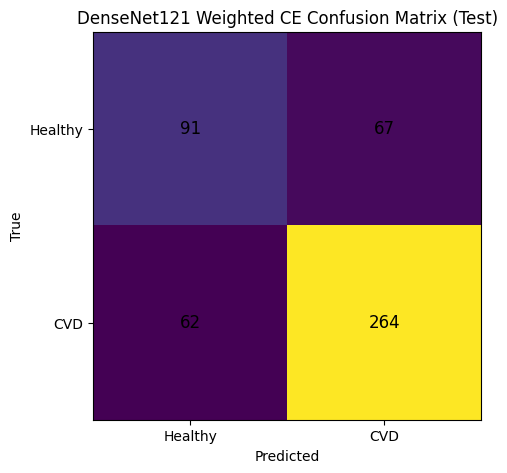

In [ ]:
from sklearn.metrics import classification_report

@torch.no_grad()
def evaluate_test(X, Y, batch=BATCH_SIZE):
    model.eval()

    N = X.size(0)
    total_loss = 0.0
    logits_all = []

    for i in range(0, N, batch):
        xb = X[i:i+batch]
        yb = Y[i:i+batch]

        with amp_ctx():
            out = model(xb)
            loss = criterion(out, yb)

        total_loss += loss.item() * yb.size(0)
        logits_all.append(out.detach())

    logits = torch.cat(logits_all, dim=0)
    y_true = Y.detach().cpu().numpy()

    mets = metrics_from_logits(logits, y_true)
    mets["loss"] = total_loss / N

    y_pred = logits.argmax(1).detach().cpu().numpy()
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

    return mets, cm, y_pred


# Test evaluation
teM, cm, y_pred = evaluate_test(Xte, Yte, batch=BATCH_SIZE)

print("\n=== TEST METRICS: DenseNet121 Weighted CE ===")
print(
    f"loss={teM['loss']:.3f} | acc={teM['acc']:.3f} | "
    f"prec={teM['prec']:.3f} | rec={teM['rec']:.3f} | "
    f"f1={teM['f1']:.3f} | auc={teM['auc']:.3f} | mcc={teM['mcc']:.3f}"
)

print("\nPer-class classification report:")
print(classification_report(Yte.detach().cpu().numpy(), y_pred, digits=3, zero_division=0))

print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm)


# Confusion matrix
try:
    tick_labels = CLASS_NAMES
    assert len(tick_labels) == NUM_CLASSES
except Exception:
    tick_labels = ["Healthy", "CVD"] if NUM_CLASSES == 2 else [str(i) for i in range(NUM_CLASSES)]

plt.figure(figsize=(5, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("DenseNet121 Weighted CE Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(NUM_CLASSES), tick_labels)
plt.yticks(range(NUM_CLASSES), tick_labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12)

plt.tight_layout()

OUT_DIR.mkdir(exist_ok=True, parents=True)
cm_path = OUT_DIR / "confusion_matrix_test_weightedCE.png"
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
print(f"\nSaved confusion matrix: {cm_path}")

plt.show()

## Save DenseNet-121 Results

In [ ]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

def _to_float(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        try: return float(np.mean(np.asarray(x, dtype=float)))
        except Exception: return float("nan")
    try: return float(x)
    except Exception: return float("nan")

# Best training and validation metrics
best_train_dn = {k: float(best_train[k]) for k in ["loss", "acc", "prec", "rec", "f1", "auc", "mcc"]}
best_val_dn = {k: float(best_val[k]) for k in ["loss", "acc", "prec", "rec", "f1", "auc", "mcc"]}

# Test metrics
_keep = ["loss", "acc", "prec", "rec", "f1", "auc", "mcc"]
teM_dn = {k: _to_float(teM.get(k, np.nan)) for k in _keep}

# Save best train/validation results
with open(OUT_DIR/"best_val_train.json", "w") as f:
    json.dump({
        "best_epoch": int(best_epoch),
        "early_stop_metric": STOP_METRIC,
        "train": best_train_dn,
        "val": best_val_dn,
        "checkpoint": str(ckpt_path)
    }, f, indent=2)

# Save test results
pd.DataFrame([teM_dn]).to_csv(OUT_DIR/"test_metrics.csv", index=False)
np.savetxt(OUT_DIR/"confusion_matrix_test.csv", cm.astype(int), fmt="%d", delimiter=",")

with open(OUT_DIR/"classification_report_test.txt", "w") as f:
    f.write(classification_report(Yte.detach().cpu().numpy(), y_pred, digits=3, zero_division=0))

print("[DenseNet results saved] ->", OUT_DIR)


[DenseNet saved] -> runs_densenet_lr1e4_ep40_weightedCE


## Handcrafted Feature Preparation for Ensemble Fusion

In [ ]:
# Image filenames from patient-wise splits
IDS_tr = tr_df["filename"].astype(str).tolist()
IDS_va = va_df["filename"].astype(str).tolist()
IDS_te = te_df["filename"].astype(str).tolist()

assert len(IDS_tr) == Xtr.size(0), "Train split rows != train tensor rows."
assert len(IDS_va) == Xva.size(0), "Val split rows != val tensor rows."
assert len(IDS_te) == Xte.size(0), "Test split rows != test tensor rows."

# Load handcrafted LBP + GLCM features
df_h = pd.read_csv(HAND_FEATS)
ID_COL = "filename"

def _align(ids, df, id_col):
    key = df[id_col].astype(str).str.replace("\\", "/", regex=False)
    base = key.str.split("/").str[-1]
    stem = base.str.replace(r"\.[^.]+$", "", regex=True)

    i_full = dict(zip(key, df.index))
    i_base = dict(zip(base, df.index))
    i_stem = dict(zip(stem, df.index))

    rows, miss = [], []

    for k in ids:
        k = str(k).replace("\\", "/")
        kb = k.split("/")[-1]
        ks = kb.rsplit(".", 1)[0]

        if k in i_full:
            rows.append(df.loc[i_full[k]])
        elif kb in i_base:
            rows.append(df.loc[i_base[kb]])
        elif ks in i_stem:
            rows.append(df.loc[i_stem[ks]])
        else:
            miss.append(k)

    if miss:
        raise ValueError(f"Missing handcrafted rows for {len(miss)} images, e.g. {miss[:8]}")

    return pd.DataFrame(rows).reset_index(drop=True)

HF_tr = _align(IDS_tr, df_h, ID_COL)
HF_va = _align(IDS_va, df_h, ID_COL)
HF_te = _align(IDS_te, df_h, ID_COL)

# Keep numeric handcrafted features only
def _num(D):
    return D.drop(columns=[ID_COL, "label", "patient_id", "eye"], errors="ignore").select_dtypes(include=[np.number])

HF_tr_np = _num(HF_tr).to_numpy(np.float32)
HF_va_np = _num(HF_va).to_numpy(np.float32)
HF_te_np = _num(HF_te).to_numpy(np.float32)

# Fit scaler on training features only
hf_scaler = StandardScaler().fit(HF_tr_np)

HFtr_s = hf_scaler.transform(HF_tr_np)
HFva_s = hf_scaler.transform(HF_va_np)
HFte_s = hf_scaler.transform(HF_te_np)

# Convert to GPU tensors
HFtr_t = torch.tensor(HFtr_s, dtype=torch.float32, device=device)
HFva_t = torch.tensor(HFva_s, dtype=torch.float32, device=device)
HFte_t = torch.tensor(HFte_s, dtype=torch.float32, device=device)

HF_DIM = HFtr_t.size(1)

print(f"Handcrafted features -> TR {HFtr_t.shape} | VA {HFva_t.shape} | TE {HFte_t.shape}")
print(f"Number of handcrafted features: {HF_DIM}")

[EF-0] Handcrafted dims -> TR torch.Size([1936, 46]) | VA torch.Size([483, 46]) | TE torch.Size([484, 46])


## DenseNet121 Fusion Training

In [ ]:
# SETTINGS 
LR_RUN = 1e-4
EPOCHS_RUN = 40
PATIENCE_RUN = 8
WEIGHT_DECAY = 1e-4
STOP_METRIC = "f1"
AUG_P = 0.5

OUT_DIR = Path("runs_densenet_fusion_lr1e4_ep40_weightedCE")
OUT_DIR.mkdir(exist_ok=True, parents=True)
Path("checkpoints").mkdir(exist_ok=True)


_device_is_cuda = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda") if _device_is_cuda else None

def amp_ctx():
    return torch.amp.autocast("cuda") if _device_is_cuda else nullcontext()

# MODEL 
class FusionDenseNet(nn.Module):
    def __init__(self, hf_dim, num_classes=2, p_drop=0.2):
        super().__init__()

        self.backbone = timm.create_model(
            "densenet121",
            pretrained=True,
            num_classes=0
        )

        self.feat_dim = self.backbone.num_features

        self.bn_img = nn.BatchNorm1d(self.feat_dim)
        self.bn_hf = nn.BatchNorm1d(hf_dim)

        self.head = nn.Sequential(
            nn.Dropout(p_drop),
            nn.Linear(self.feat_dim + hf_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(512, num_classes)
        )

    def forward(self, x_img, x_hf):
        z = self.backbone(x_img)
        z = self.bn_img(z)

        h = self.bn_hf(x_hf)

        out = torch.cat([z, h], dim=1)
        return self.head(out)

fusion = FusionDenseNet(
    hf_dim=HF_DIM,
    num_classes=NUM_CLASSES,
    p_drop=0.2
).to(device)

# Freeze backbone first; train fusion head + BN layers
for p in fusion.backbone.parameters():
    p.requires_grad = False

# WEIGHTED CE LOSS
class_counts = torch.bincount(Ytr.detach().cpu(), minlength=NUM_CLASSES).float()
class_weights = class_counts.sum() / (NUM_CLASSES * class_counts)
class_weights = class_weights.to(device)

print("Class counts:", class_counts.tolist())
print("Class weights:", class_weights.detach().cpu().tolist())

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    [
        {"params": fusion.head.parameters(), "lr": LR_RUN},
        {"params": fusion.bn_img.parameters(), "lr": LR_RUN},
        {"params": fusion.bn_hf.parameters(), "lr": LR_RUN},
    ],
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

# AUGMENTATION
def augment_fusion_gpu(x):
    if not fusion.training:
        return x

    if torch.rand(1, device=x.device) < AUG_P:
        x = torch.flip(x, dims=[3])

    b = (torch.rand(x.size(0), 1, 1, 1, device=x.device) - 0.5) * 0.10
    c = 1.0 + (torch.rand(x.size(0), 1, 1, 1, device=x.device) - 0.5) * 0.10
    x = (x * c + b).clamp_(-4, 4)

    return x

# ONE EPOCH
def _epoch_fusion(X, HF, Y, train=True, batch=BATCH_SIZE):
    fusion.train(train)

    N = X.size(0)
    order = torch.randperm(N, device=device) if train else torch.arange(N, device=device)

    total_loss = 0.0
    logits_all = []

    for i in range(0, N, batch):
        idx = order[i:i+batch]
        xb = X[idx]
        hb = HF[idx]
        yb = Y[idx]

        if train:
            xb = augment_fusion_gpu(xb)

        with amp_ctx():
            out = fusion(xb, hb)
            loss = criterion(out, yb)

        if train:
            optimizer.zero_grad(set_to_none=True)

            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * yb.size(0)
        logits_all.append(out.detach())

    logits = torch.cat(logits_all, dim=0)
    mets = metrics_from_logits(logits, Y.detach().cpu().numpy())
    mets["loss"] = total_loss / N

    return mets

# TRAIN LOOP
best_score = -1.0
best_state = None
best_epoch = -1
best_val = None
best_train = None
pat = PATIENCE_RUN
history = []

for ep in range(1, EPOCHS_RUN + 1):
    trM = _epoch_fusion(Xtr, HFtr_t, Ytr, train=True, batch=BATCH_SIZE)
    vaM = _epoch_fusion(Xva, HFva_t, Yva, train=False, batch=BATCH_SIZE)

    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": ep,
        "lr": current_lr,
        "tr_loss": trM["loss"], "tr_acc": trM["acc"], "tr_prec": trM["prec"],
        "tr_rec": trM["rec"], "tr_f1": trM["f1"], "tr_auc": trM["auc"], "tr_mcc": trM["mcc"],
        "va_loss": vaM["loss"], "va_acc": vaM["acc"], "va_prec": vaM["prec"],
        "va_rec": vaM["rec"], "va_f1": vaM["f1"], "va_auc": vaM["auc"], "va_mcc": vaM["mcc"]
    })

    print(
        f"[Ep {ep:02d}] LR={current_lr:.2e} | "
        f"TR L={trM['loss']:.3f} A={trM['acc']:.3f} F1={trM['f1']:.3f} AUC={trM['auc']:.3f} | "
        f"VA L={vaM['loss']:.3f} A={vaM['acc']:.3f} F1={vaM['f1']:.3f} AUC={vaM['auc']:.3f}"
    )

    scheduler.step(vaM[STOP_METRIC])

    score = vaM[STOP_METRIC]

    if score > best_score:
        best_score = score
        best_state = {k: v.detach().cpu() for k, v in fusion.state_dict().items()}
        best_epoch = ep
        best_val = vaM.copy()
        best_train = trM.copy()
        pat = PATIENCE_RUN
    else:
        pat -= 1
        if pat <= 0:
            print("Early stop.")
            break

# ESTORE BEST CHECKPOINT
ckpt_path = "checkpoints/densenet_fusion_best_lr1e4_ep40_weightedCE.pth"

if best_state is not None:
    torch.save(best_state, ckpt_path)
    fusion.load_state_dict(best_state, strict=True)


log_df = pd.DataFrame(history)
csv_path = OUT_DIR / "train_val_metrics.csv"

try:
    log_df.to_csv(csv_path, index=False)
except PermissionError:
    csv_path = OUT_DIR / f"train_val_metrics_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    log_df.to_csv(csv_path, index=False)

# PRINT BEST METRICS
print(f"\n=== Best FusionDenseNet checkpoint by val {STOP_METRIC.upper()} at epoch {best_epoch} ===")

print("VAL:")
print(
    f"  loss={best_val['loss']:.3f} | acc={best_val['acc']:.3f} | "
    f"prec={best_val['prec']:.3f} | rec={best_val['rec']:.3f} | "
    f"f1={best_val['f1']:.3f} | auc={best_val['auc']:.3f} | mcc={best_val['mcc']:.3f}"
)

print("TRAIN:")
print(
    f"  loss={best_train['loss']:.3f} | acc={best_train['acc']:.3f} | "
    f"prec={best_train['prec']:.3f} | rec={best_train['rec']:.3f} | "
    f"f1={best_train['f1']:.3f} | auc={best_train['auc']:.3f} | mcc={best_train['mcc']:.3f}"
)

print(f"\nCheckpoint saved to: {ckpt_path}")
print(f"History CSV saved to: {csv_path}")

# THRESHOLD TUNING ON VALIDATION SET
@torch.no_grad()
def _val_probs_fusion(X, HF, batch=BATCH_SIZE):
    fusion.eval()
    probs = []

    for i in range(0, X.size(0), batch):
        xb = X[i:i+batch]
        hb = HF[i:i+batch]

        with amp_ctx():
            logits = fusion(xb, hb)

        probs.append(torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy())

    return np.concatenate(probs, axis=0)

va_prob = _val_probs_fusion(Xva, HFva_t, batch=BATCH_SIZE)
yva_np = Yva.detach().cpu().numpy()

ths = np.linspace(0.2, 0.8, 61)
best_thr = 0.5
best_f1_tune = -1.0

for t in ths:
    pred = (va_prob >= t).astype(int)
    _, _, f1_t, _ = precision_recall_fscore_support(
        yva_np,
        pred,
        average="macro",
        zero_division=0
    )

    if f1_t > best_f1_tune:
        best_f1_tune = f1_t
        best_thr = t

THRESHOLD = float(best_thr)

print(f"[Threshold] Selected τ*={THRESHOLD:.3f} using VAL macro-F1={best_f1_tune:.3f}")

Class counts: [567.0, 1369.0]
Class weights: [1.707231044769287, 0.7070854902267456]
[Ep 01] LR=1.00e-04 | TR L=0.652 A=0.514 F1=0.484 AUC=0.500 | VA L=0.574 A=0.735 F1=0.682 AUC=0.774
[Ep 02] LR=1.00e-04 | TR L=0.576 A=0.521 F1=0.475 AUC=0.468 | VA L=0.548 A=0.712 F1=0.681 AUC=0.810
[Ep 03] LR=1.00e-04 | TR L=0.536 A=0.545 F1=0.489 AUC=0.502 | VA L=0.527 A=0.739 F1=0.703 AUC=0.820
[Ep 04] LR=1.00e-04 | TR L=0.515 A=0.552 F1=0.494 AUC=0.499 | VA L=0.530 A=0.723 F1=0.689 AUC=0.817
[Ep 05] LR=1.00e-04 | TR L=0.503 A=0.552 F1=0.495 AUC=0.493 | VA L=0.523 A=0.723 F1=0.690 AUC=0.820
[Ep 06] LR=1.00e-04 | TR L=0.481 A=0.553 F1=0.497 AUC=0.496 | VA L=0.518 A=0.739 F1=0.704 AUC=0.822
[Ep 07] LR=1.00e-04 | TR L=0.474 A=0.574 F1=0.516 AUC=0.534 | VA L=0.518 A=0.752 F1=0.713 AUC=0.821
[Ep 08] LR=1.00e-04 | TR L=0.460 A=0.559 F1=0.501 AUC=0.495 | VA L=0.524 A=0.745 F1=0.707 AUC=0.815
[Ep 09] LR=1.00e-04 | TR L=0.448 A=0.555 F1=0.496 AUC=0.493 | VA L=0.528 A=0.741 F1=0.699 AUC=0.810
[Ep 10] LR=1.00

## DenseNet121 Fusion Test Evaluation


=== TEST METRICS: FusionDenseNet @ τ* ===
  acc=0.752 | prec=0.717 | rec=0.705 | f1=0.710 | auc=0.780 | mcc=0.422

Per-class TEST report:
              precision    recall  f1-score   support

           0      0.634     0.570     0.600       158
           1      0.801     0.840     0.820       326

    accuracy                          0.752       484
   macro avg      0.717     0.705     0.710       484
weighted avg      0.747     0.752     0.748       484


Confusion Matrix (rows=true, cols=pred):
[[ 90  68]
 [ 52 274]]
[Saved] runs_densenet_fusion_lr1e4_ep40_weightedCE\confusion_matrix_test_fusion_thr.png


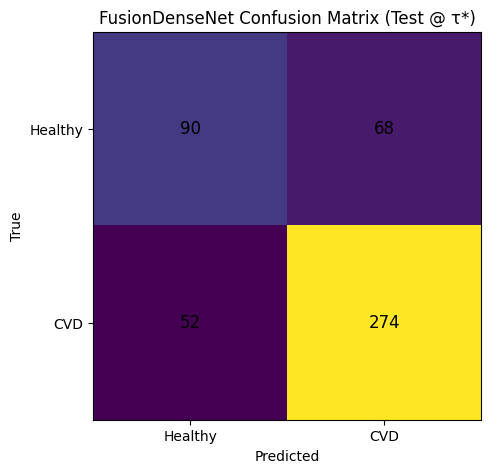

In [ ]:
@torch.no_grad()
def _test_probs_logits_fusion(X, HF, batch=BATCH_SIZE):
    fusion.eval()
    probs, logits_all = [], []

    for i in range(0, X.size(0), batch):
        xb = X[i:i+batch]
        hb = HF[i:i+batch]

        with amp_ctx():
            logits = fusion(xb, hb)

        probs.append(torch.softmax(logits, dim=1)[:, 1].detach().cpu())
        logits_all.append(logits.detach().cpu())

    return torch.cat(probs).numpy(), torch.cat(logits_all)

# Test
te_prob, te_logits = _test_probs_logits_fusion(Xte, HFte_t, batch=BATCH_SIZE)

yte_np = Yte.detach().cpu().numpy()
yhat = (te_prob >= THRESHOLD).astype(int)

acc = accuracy_score(yte_np, yhat)
prec, rec, f1, _ = precision_recall_fscore_support(yte_np, yhat, average="macro", zero_division=0)
auc = roc_auc_score(yte_np, te_prob)
mcc = matthews_corrcoef(yte_np, yhat)
cm = confusion_matrix(yte_np, yhat, labels=list(range(NUM_CLASSES)))

print("\n=== TEST METRICS: DenseNet121 Fusion @ τ* ===")
print(
    f"  acc={acc:.3f} | prec={prec:.3f} | rec={rec:.3f} | "
    f"f1={f1:.3f} | auc={auc:.3f} | mcc={mcc:.3f}"
)

print("\nPer-class TEST report:")
print(classification_report(yte_np, yhat, digits=3, zero_division=0))

print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm)

# Confusion matrix
try:
    labels = CLASS_NAMES
    assert len(labels) == NUM_CLASSES
except Exception:
    labels = ["Healthy", "CVD"] if NUM_CLASSES == 2 else [str(i) for i in range(NUM_CLASSES)]

plt.figure(figsize=(5, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("DenseNet121 Fusion Confusion Matrix (Test @ τ*)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(NUM_CLASSES), labels)
plt.yticks(range(NUM_CLASSES), labels)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12)

plt.tight_layout()

pth = OUT_DIR / "confusion_matrix_test_fusion_thr.png"
plt.savefig(pth, dpi=200, bbox_inches="tight")

print(f"\n[Saved] Confusion matrix figure -> {pth}")
plt.show()

## EfficientNet-B3 Training

In [ ]:
# Settings
LR_RUN = 1e-4
EPOCHS_RUN = 40
PATIENCE_RUN = 8
WEIGHT_DECAY = 1e-4
STOP_METRIC = "f1"
AUG_P = 0.5

OUT_DIR_E = Path("runs_efficientnet_b3_lr1e4_ep40_weightedCE")
OUT_DIR_E.mkdir(exist_ok=True, parents=True)
Path("checkpoints").mkdir(exist_ok=True)

# Model
model = timm.create_model("tf_efficientnet_b3_ns", pretrained=True, num_classes=NUM_CLASSES).to(device)

# Weighted CE loss
class_counts = torch.bincount(Ytr.detach().cpu(), minlength=NUM_CLASSES).float()
class_weights = (class_counts.sum() / (NUM_CLASSES * class_counts)).to(device)

print("Class counts:", class_counts.tolist())
print("Class weights:", class_weights.detach().cpu().tolist())

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR_RUN, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

# AMP
_device_is_cuda = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda") if _device_is_cuda else None

def amp_ctx():
    return torch.amp.autocast("cuda") if _device_is_cuda else nullcontext()

# Augmentation
def augment_gpu(x):
    if not model.training:
        return x

    if torch.rand(1, device=x.device) < AUG_P:
        x = torch.flip(x, dims=[3])

    b = (torch.rand(x.size(0), 1, 1, 1, device=x.device) - 0.5) * 0.10
    c = 1.0 + (torch.rand(x.size(0), 1, 1, 1, device=x.device) - 0.5) * 0.10
    return (x * c + b).clamp_(-4, 4)

# One epoch
def _epoch_gpu_full(X, Y, train=True, batch=BATCH_SIZE):
    model.train(train)

    N = X.size(0)
    order = torch.randperm(N, device=device) if train else torch.arange(N, device=device)

    total_loss = 0.0
    logits_all = []

    for i in range(0, N, batch):
        idx = order[i:i+batch]
        xb, yb = X[idx], Y[idx]

        if train:
            xb = augment_gpu(xb)

        with amp_ctx():
            out = model(xb)
            loss = criterion(out, yb)

        if train:
            optimizer.zero_grad(set_to_none=True)

            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * yb.size(0)
        logits_all.append(out.detach())

    logits_cat = torch.cat(logits_all, dim=0)
    mets = metrics_from_logits(logits_cat, Y.detach().cpu().numpy())
    mets["loss"] = total_loss / N

    return mets

# Training
best_score = -1.0
best_state = None
best_epoch = -1
best_val = None
best_train = None
pat = PATIENCE_RUN
history = []

for ep in range(1, EPOCHS_RUN + 1):
    trM = _epoch_gpu_full(Xtr, Ytr, train=True, batch=BATCH_SIZE)
    vaM = _epoch_gpu_full(Xva, Yva, train=False, batch=BATCH_SIZE)

    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": ep, "lr": current_lr,
        "tr_loss": trM["loss"], "tr_acc": trM["acc"], "tr_prec": trM["prec"],
        "tr_rec": trM["rec"], "tr_f1": trM["f1"], "tr_auc": trM["auc"], "tr_mcc": trM["mcc"],
        "va_loss": vaM["loss"], "va_acc": vaM["acc"], "va_prec": vaM["prec"],
        "va_rec": vaM["rec"], "va_f1": vaM["f1"], "va_auc": vaM["auc"], "va_mcc": vaM["mcc"]
    })

    print(
        f"[Ep {ep:02d}] LR={current_lr:.2e} | "
        f"TR L={trM['loss']:.3f} A={trM['acc']:.3f} F1={trM['f1']:.3f} AUC={trM['auc']:.3f} | "
        f"VA L={vaM['loss']:.3f} A={vaM['acc']:.3f} F1={vaM['f1']:.3f} AUC={vaM['auc']:.3f}"
    )

    scheduler.step(vaM[STOP_METRIC])
    score = vaM[STOP_METRIC]

    if score > best_score:
        best_score = score
        best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
        best_epoch = ep
        best_val = vaM.copy()
        best_train = trM.copy()
        pat = PATIENCE_RUN
    else:
        pat -= 1
        if pat <= 0:
            print("Early stop.")
            break

# Save best model
ckpt_path_e = "checkpoints/efficientnet_b3_best_lr1e4_ep40_weightedCE.pth"

if best_state is not None:
    torch.save(best_state, ckpt_path_e)
    model.load_state_dict(best_state, strict=True)

# Save training log
log_df = pd.DataFrame(history)
csv_path_e = OUT_DIR_E / "train_val_metrics.csv"

try:
    log_df.to_csv(csv_path_e, index=False)
except PermissionError:
    csv_path_e = OUT_DIR_E / f"train_val_metrics_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    log_df.to_csv(csv_path_e, index=False)

# Best results
print(f"\n=== Best EfficientNet-B3 Weighted-CE checkpoint by val {STOP_METRIC.upper()} at epoch {best_epoch} ===")

print("VAL:")
print(
    f"  loss={best_val['loss']:.3f} | acc={best_val['acc']:.3f} | "
    f"prec={best_val['prec']:.3f} | rec={best_val['rec']:.3f} | "
    f"f1={best_val['f1']:.3f} | auc={best_val['auc']:.3f} | mcc={best_val['mcc']:.3f}"
)

print("TRAIN:")
print(
    f"  loss={best_train['loss']:.3f} | acc={best_train['acc']:.3f} | "
    f"prec={best_train['prec']:.3f} | rec={best_train['rec']:.3f} | "
    f"f1={best_train['f1']:.3f} | auc={best_train['auc']:.3f} | mcc={best_train['mcc']:.3f}"
)

print(f"\nCheckpoint saved to: {ckpt_path_e}")
print(f"History CSV saved to: {csv_path_e}")

C:\Users\Shri\AppData\Roaming\Python\Python311\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name tf_efficientnet_b3_ns to current tf_efficientnet_b3.ns_jft_in1k.
  model = create_fn(


Class counts: [567.0, 1369.0]
Class weights: [1.707231044769287, 0.7070854902267456]
[Ep 01] LR=1.00e-04 | TR L=1.293 A=0.518 F1=0.485 AUC=0.506 | VA L=1.265 A=0.588 F1=0.537 AUC=0.598
[Ep 02] LR=1.00e-04 | TR L=0.584 A=0.567 F1=0.516 AUC=0.530 | VA L=0.871 A=0.733 F1=0.672 AUC=0.748
[Ep 03] LR=1.00e-04 | TR L=0.299 A=0.575 F1=0.507 AUC=0.511 | VA L=0.861 A=0.708 F1=0.656 AUC=0.752
[Ep 04] LR=1.00e-04 | TR L=0.225 A=0.594 F1=0.522 AUC=0.516 | VA L=0.843 A=0.729 F1=0.677 AUC=0.772
[Ep 05] LR=1.00e-04 | TR L=0.146 A=0.581 F1=0.504 AUC=0.521 | VA L=0.896 A=0.741 F1=0.697 AUC=0.776
[Ep 06] LR=1.00e-04 | TR L=0.078 A=0.581 F1=0.497 AUC=0.485 | VA L=0.999 A=0.758 F1=0.700 AUC=0.771
[Ep 07] LR=1.00e-04 | TR L=0.079 A=0.567 F1=0.480 AUC=0.486 | VA L=0.986 A=0.754 F1=0.701 AUC=0.779
[Ep 08] LR=1.00e-04 | TR L=0.046 A=0.596 F1=0.514 AUC=0.528 | VA L=0.966 A=0.762 F1=0.706 AUC=0.795
[Ep 09] LR=1.00e-04 | TR L=0.034 A=0.581 F1=0.497 AUC=0.514 | VA L=0.992 A=0.756 F1=0.702 AUC=0.801
[Ep 10] LR=1.00

## EfficientNet-B3 Test Evaluation


=== TEST METRICS: EfficientNet-B3 Weighted CE ===
  loss=1.631 | acc=0.729 | prec=0.690 | rec=0.672 | f1=0.678 | auc=0.734 | mcc=0.361

Per-class classification report:
              precision    recall  f1-score   support

           0      0.602     0.506     0.550       158
           1      0.778     0.837     0.806       326

    accuracy                          0.729       484
   macro avg      0.690     0.672     0.678       484
weighted avg      0.720     0.729     0.723       484


Confusion Matrix (rows=true, cols=pred):
[[ 80  78]
 [ 53 273]]

[Saved] Confusion matrix figure -> runs_efficientnet_b3_lr1e4_ep40_weightedCE\confusion_matrix_test_weightedCE.png


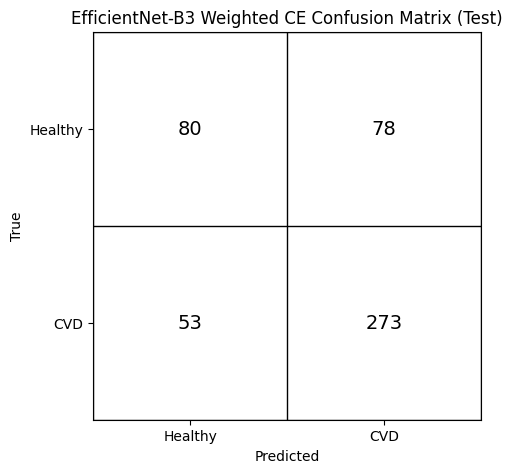

In [ ]:
@torch.no_grad()
def evaluate_test_eff(X, Y, batch=BATCH_SIZE):
    model.eval()

    N = X.size(0)
    total_loss = 0.0
    logits_all = []

    for i in range(0, N, batch):
        xb = X[i:i+batch]
        yb = Y[i:i+batch]

        with amp_ctx():
            out = model(xb)
            loss = criterion(out, yb)

        total_loss += loss.item() * yb.size(0)
        logits_all.append(out.detach())

    logits = torch.cat(logits_all, dim=0)
    y_true = Y.detach().cpu().numpy()

    mets = metrics_from_logits(logits, y_true)
    mets["loss"] = total_loss / N

    y_pred = logits.argmax(1).detach().cpu().numpy()
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

    return mets, cm, y_pred

# Test evaluation
teM_e, cm_e, y_pred_e = evaluate_test_eff(Xte, Yte, batch=BATCH_SIZE)

print("\n=== TEST METRICS: EfficientNet-B3 Weighted CE ===")
print(
    f"  loss={teM_e['loss']:.3f} | acc={teM_e['acc']:.3f} | "
    f"prec={teM_e['prec']:.3f} | rec={teM_e['rec']:.3f} | "
    f"f1={teM_e['f1']:.3f} | auc={teM_e['auc']:.3f} | mcc={teM_e['mcc']:.3f}"
)

print("\nPer-class classification report:")
print(classification_report(Yte.detach().cpu().numpy(), y_pred_e, digits=3, zero_division=0))

print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm_e)

# Confusion matrix
try:
    tick_labels = CLASS_NAMES
    assert len(tick_labels) == NUM_CLASSES
except Exception:
    tick_labels = ["Healthy", "CVD"] if NUM_CLASSES == 2 else [str(i) for i in range(NUM_CLASSES)]

plt.figure(figsize=(5, 5))
ax = plt.gca()

H, W = cm_e.shape
ax.imshow(np.ones((H, W)), vmin=0, vmax=1, cmap="gray", interpolation="nearest")
ax.set_aspect("equal")

ax.set_xticks(range(W))
ax.set_yticks(range(H))
ax.set_xticklabels(tick_labels)
ax.set_yticklabels(tick_labels)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("EfficientNet-B3 Weighted CE Confusion Matrix (Test)")

ax.set_xticks(np.arange(-0.5, W, 1), minor=True)
ax.set_yticks(np.arange(-0.5, H, 1), minor=True)
ax.grid(which="minor", color="black", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(H):
    for j in range(W):
        ax.text(j, i, str(cm_e[i, j]), ha="center", va="center", fontsize=14, color="black")

plt.tight_layout()

try:
    OUT_DIR_E.mkdir(exist_ok=True, parents=True)
    cm_path_e = OUT_DIR_E / "confusion_matrix_test_weightedCE.png"
    plt.savefig(cm_path_e, dpi=200, bbox_inches="tight", facecolor="white")
    print(f"\n[Saved] Confusion matrix figure -> {cm_path_e}")
except Exception as e:
    print(f"\n[Info] Could not save confusion matrix figure: {e}")

plt.show()

## EfficientNet-B3 Fusion Training

In [ ]:
# Settings
LR_RUN = 1e-4
EPOCHS_RUN = 40
PATIENCE_RUN = 8
WEIGHT_DECAY = 1e-4
STOP_METRIC = "f1"
AUG_P = 0.5

OUT_DIR_F = Path("runs_efficientnet_b3_fusion_lr1e4_ep40_weightedCE")
OUT_DIR_F.mkdir(exist_ok=True, parents=True)
Path("checkpoints").mkdir(exist_ok=True)

# AMP
_device_is_cuda = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda") if _device_is_cuda else None

def amp_ctx():
    return torch.amp.autocast("cuda") if _device_is_cuda else nullcontext()

# Model
class FusionEffB3(nn.Module):
    def __init__(self, hf_dim, num_classes=2, p_drop=0.2):
        super().__init__()

        self.backbone = timm.create_model("tf_efficientnet_b3_ns", pretrained=True, num_classes=0)
        self.feat_dim = self.backbone.num_features

        self.img_proj = nn.Sequential(
            nn.LayerNorm(self.feat_dim),
            nn.Linear(self.feat_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop)
        )

        self.hf_proj = nn.Sequential(
            nn.LayerNorm(hf_dim),
            nn.Linear(hf_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop)
        )

        self.head = nn.Sequential(
            nn.Linear(512 + 256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(512, num_classes)
        )

    def forward(self, x_img, x_hf):
        z = self.img_proj(self.backbone(x_img))
        h = self.hf_proj(x_hf)
        return self.head(torch.cat([z, h], dim=1))

fusion = FusionEffB3(hf_dim=HFtr_t.size(1), num_classes=NUM_CLASSES, p_drop=0.2).to(device)

# Freeze backbone
for p in fusion.backbone.parameters():
    p.requires_grad = False

# Weighted CE loss
class_counts = torch.bincount(Ytr.detach().cpu(), minlength=NUM_CLASSES).float()
class_weights = (class_counts.sum() / (NUM_CLASSES * class_counts)).to(device)

print("Class counts:", class_counts.tolist())
print("Class weights:", class_weights.detach().cpu().tolist())

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    [
        {"params": fusion.img_proj.parameters(), "lr": LR_RUN},
        {"params": fusion.hf_proj.parameters(), "lr": LR_RUN},
        {"params": fusion.head.parameters(), "lr": LR_RUN},
    ],
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

# Augmentation
def augment_fusion_gpu(x):
    if not fusion.training:
        return x

    if torch.rand(1, device=x.device) < AUG_P:
        x = torch.flip(x, dims=[3])

    b = (torch.rand(x.size(0), 1, 1, 1, device=x.device) - 0.5) * 0.10
    c = 1.0 + (torch.rand(x.size(0), 1, 1, 1, device=x.device) - 0.5) * 0.10
    return (x * c + b).clamp_(-4, 4)

# One epoch
def _epoch_effb3_fusion(X, HF, Y, train=True, batch=BATCH_SIZE):
    fusion.train(train)

    N = X.size(0)
    order = torch.randperm(N, device=device) if train else torch.arange(N, device=device)

    total_loss = 0.0
    logits_all = []

    for i in range(0, N, batch):
        idx = order[i:i+batch]
        xb, hb, yb = X[idx], HF[idx], Y[idx]

        if train:
            xb = augment_fusion_gpu(xb)

        with amp_ctx():
            out = fusion(xb, hb)
            loss = criterion(out, yb)

        if train:
            optimizer.zero_grad(set_to_none=True)

            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * yb.size(0)
        logits_all.append(out.detach())

    logits = torch.cat(logits_all, dim=0)
    mets = metrics_from_logits(logits, Y.detach().cpu().numpy())
    mets["loss"] = total_loss / N

    return mets

# Training
best_score = -1.0
best_state = None
best_epoch = -1
best_val = None
best_train = None
pat = PATIENCE_RUN
history = []

for ep in range(1, EPOCHS_RUN + 1):
    trM = _epoch_effb3_fusion(Xtr, HFtr_t, Ytr, train=True, batch=BATCH_SIZE)
    vaM = _epoch_effb3_fusion(Xva, HFva_t, Yva, train=False, batch=BATCH_SIZE)

    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": ep, "lr": current_lr,
        "tr_loss": trM["loss"], "tr_acc": trM["acc"], "tr_prec": trM["prec"],
        "tr_rec": trM["rec"], "tr_f1": trM["f1"], "tr_auc": trM["auc"], "tr_mcc": trM["mcc"],
        "va_loss": vaM["loss"], "va_acc": vaM["acc"], "va_prec": vaM["prec"],
        "va_rec": vaM["rec"], "va_f1": vaM["f1"], "va_auc": vaM["auc"], "va_mcc": vaM["mcc"]
    })

    print(
        f"[Ep {ep:02d}] LR={current_lr:.2e} | "
        f"TR L={trM['loss']:.3f} A={trM['acc']:.3f} F1={trM['f1']:.3f} AUC={trM['auc']:.3f} | "
        f"VA L={vaM['loss']:.3f} A={vaM['acc']:.3f} F1={vaM['f1']:.3f} AUC={vaM['auc']:.3f}"
    )

    scheduler.step(vaM[STOP_METRIC])
    score = vaM[STOP_METRIC]

    if score > best_score:
        best_score = score
        best_state = {k: v.detach().cpu() for k, v in fusion.state_dict().items()}
        best_epoch = ep
        best_val = vaM.copy()
        best_train = trM.copy()
        pat = PATIENCE_RUN
    else:
        pat -= 1
        if pat <= 0:
            print("Early stop.")
            break

# Save best model
ckpt_path_f = "checkpoints/efficientnet_b3_fusion_best_lr1e4_ep40_weightedCE.pth"

if best_state is not None:
    torch.save(best_state, ckpt_path_f)
    fusion.load_state_dict(best_state, strict=True)

# Save training log
log_df = pd.DataFrame(history)
csv_path_f = OUT_DIR_F / "train_val_metrics.csv"

try:
    log_df.to_csv(csv_path_f, index=False)
except PermissionError:
    csv_path_f = OUT_DIR_F / f"train_val_metrics_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    log_df.to_csv(csv_path_f, index=False)

# Best results
print(f"\n=== Best FusionEfficientNet-B3 checkpoint by val {STOP_METRIC.upper()} at epoch {best_epoch} ===")

print("VAL:")
print(
    f"  loss={best_val['loss']:.3f} | acc={best_val['acc']:.3f} | "
    f"prec={best_val['prec']:.3f} | rec={best_val['rec']:.3f} | "
    f"f1={best_val['f1']:.3f} | auc={best_val['auc']:.3f} | mcc={best_val['mcc']:.3f}"
)

print("TRAIN:")
print(
    f"  loss={best_train['loss']:.3f} | acc={best_train['acc']:.3f} | "
    f"prec={best_train['prec']:.3f} | rec={best_train['rec']:.3f} | "
    f"f1={best_train['f1']:.3f} | auc={best_train['auc']:.3f} | mcc={best_train['mcc']:.3f}"
)

print(f"\nCheckpoint saved to: {ckpt_path_f}")
print(f"History CSV saved to: {csv_path_f}")

# Validation threshold tuning
@torch.no_grad()
def _val_probs_effb3_fusion(X, HF, batch=BATCH_SIZE):
    fusion.eval()
    probs = []

    for i in range(0, X.size(0), batch):
        xb = X[i:i+batch]
        hb = HF[i:i+batch]

        with amp_ctx():
            logits = fusion(xb, hb)

        probs.append(torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy())

    return np.concatenate(probs, axis=0)

va_prob = _val_probs_effb3_fusion(Xva, HFva_t, batch=BATCH_SIZE)
yva_np = Yva.detach().cpu().numpy()

ths = np.linspace(0.2, 0.8, 61)
best_thr = 0.5
best_f1_tune = -1.0

for t in ths:
    pred = (va_prob >= t).astype(int)
    _, _, f1_t, _ = precision_recall_fscore_support(
        yva_np, pred, average="macro", zero_division=0
    )

    if f1_t > best_f1_tune:
        best_f1_tune = f1_t
        best_thr = t

THRESHOLD = float(best_thr)

print(f"[Threshold] Selected τ*={THRESHOLD:.3f} using VAL macro-F1={best_f1_tune:.3f}")

C:\Users\Shri\AppData\Roaming\Python\Python311\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name tf_efficientnet_b3_ns to current tf_efficientnet_b3.ns_jft_in1k.
  model = create_fn(


Class counts: [567.0, 1369.0]
Class weights: [1.707231044769287, 0.7070854902267456]
[Ep 01] LR=1.00e-04 | TR L=0.640 A=0.565 F1=0.506 AUC=0.491 | VA L=0.607 A=0.731 F1=0.660 AUC=0.728
[Ep 02] LR=1.00e-04 | TR L=0.574 A=0.556 F1=0.509 AUC=0.526 | VA L=0.554 A=0.745 F1=0.696 AUC=0.786
[Ep 03] LR=1.00e-04 | TR L=0.542 A=0.546 F1=0.491 AUC=0.508 | VA L=0.561 A=0.702 F1=0.670 AUC=0.788
[Ep 04] LR=1.00e-04 | TR L=0.501 A=0.545 F1=0.496 AUC=0.511 | VA L=0.552 A=0.745 F1=0.698 AUC=0.787
[Ep 05] LR=1.00e-04 | TR L=0.465 A=0.562 F1=0.507 AUC=0.496 | VA L=0.559 A=0.729 F1=0.682 AUC=0.788
[Ep 06] LR=1.00e-04 | TR L=0.441 A=0.542 F1=0.489 AUC=0.492 | VA L=0.568 A=0.737 F1=0.692 AUC=0.787
[Ep 07] LR=1.00e-04 | TR L=0.417 A=0.565 F1=0.504 AUC=0.507 | VA L=0.591 A=0.762 F1=0.700 AUC=0.783
[Ep 08] LR=1.00e-04 | TR L=0.392 A=0.549 F1=0.488 AUC=0.488 | VA L=0.603 A=0.752 F1=0.694 AUC=0.774
[Ep 09] LR=1.00e-04 | TR L=0.364 A=0.558 F1=0.494 AUC=0.513 | VA L=0.603 A=0.764 F1=0.707 AUC=0.782
[Ep 10] LR=1.00

## EfficientNet-B3 Fusion Test Evaluation


=== TEST METRICS: EfficientNet-B3 Fusion @ τ* ===
  acc=0.721 | prec=0.680 | rec=0.669 | f1=0.673 | auc=0.749 | mcc=0.349

Per-class TEST report:
              precision    recall  f1-score   support

           0      0.582     0.519     0.548       158
           1      0.778     0.819     0.798       326

    accuracy                          0.721       484
   macro avg      0.680     0.669     0.673       484
weighted avg      0.714     0.721     0.717       484


Confusion Matrix (rows=true, cols=pred):
[[ 82  76]
 [ 59 267]]
[Saved] runs_efficientnet_b3_fusion_lr1e4_ep40_weightedCE\confusion_matrix_test_fusion_thr.png


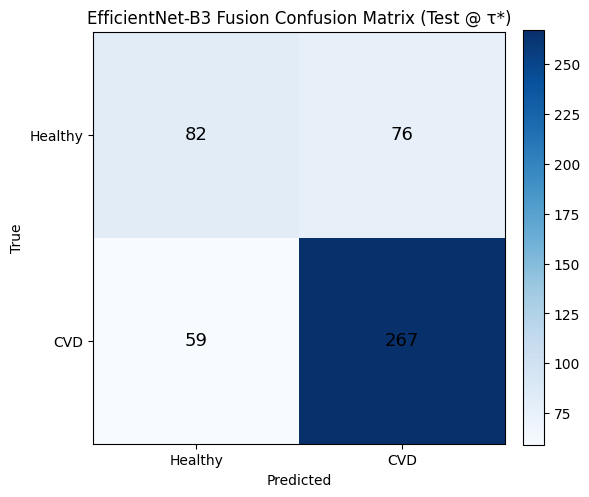

In [ ]:
@torch.no_grad()
def _test_probs_logits_effb3(X, HF, batch=BATCH_SIZE):
    fusion.eval()
    probs, logits_all = [], []

    for i in range(0, X.size(0), batch):
        xb = X[i:i+batch]
        hb = HF[i:i+batch]

        with amp_ctx():
            logits = fusion(xb, hb)

        probs.append(torch.softmax(logits, dim=1)[:, 1].detach().cpu())
        logits_all.append(logits.detach().cpu())

    return torch.cat(probs).numpy(), torch.cat(logits_all)

# Test
te_prob, te_logits = _test_probs_logits_effb3(Xte, HFte_t, batch=BATCH_SIZE)

yte_np = Yte.detach().cpu().numpy()
yhat = (te_prob >= THRESHOLD).astype(int)

acc = accuracy_score(yte_np, yhat)
prec, rec, f1, _ = precision_recall_fscore_support(yte_np, yhat, average="macro", zero_division=0)
auc = roc_auc_score(yte_np, te_prob)
mcc = matthews_corrcoef(yte_np, yhat)
cm = confusion_matrix(yte_np, yhat, labels=list(range(NUM_CLASSES)))

print("\n=== TEST METRICS: EfficientNet-B3 Fusion @ τ* ===")
print(
    f"  acc={acc:.3f} | prec={prec:.3f} | rec={rec:.3f} | "
    f"f1={f1:.3f} | auc={auc:.3f} | mcc={mcc:.3f}"
)

print("\nPer-class TEST report:")
print(classification_report(yte_np, yhat, digits=3, zero_division=0))

print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm)

# Confusion matrix
try:
    labels = CLASS_NAMES
    assert len(labels) == NUM_CLASSES
except Exception:
    labels = ["Healthy", "CVD"] if NUM_CLASSES == 2 else [str(i) for i in range(NUM_CLASSES)]

plt.figure(figsize=(6, 6))
im = plt.imshow(cm, cmap="Blues")
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.title("EfficientNet-B3 Fusion Confusion Matrix (Test @ τ*)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(NUM_CLASSES), labels)
plt.yticks(range(NUM_CLASSES), labels)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=13, color="black")

plt.tight_layout()

pth = OUT_DIR_F / "confusion_matrix_test_fusion_thr.png"
plt.savefig(pth, dpi=220, bbox_inches="tight")

print(f"[Saved] {pth}")
plt.show()

## MobileNetV3-Large Training

In [ ]:
LR_RUN = 1e-4
EPOCHS_RUN = 40
PATIENCE_RUN = 8
WEIGHT_DECAY = 1e-4
STOP_METRIC = "f1"
AUG_P = 0.5

OUT_DIR_M = Path("runs_mobilenetv3_lr1e4_ep40_weightedCE")
OUT_DIR_M.mkdir(exist_ok=True, parents=True)
Path("checkpoints").mkdir(exist_ok=True)

# Model
model = timm.create_model("mobilenetv3_large_100", pretrained=True, num_classes=NUM_CLASSES).to(device)

# Weighted CE loss
class_counts = torch.bincount(Ytr.detach().cpu(), minlength=NUM_CLASSES).float()
class_weights = (class_counts.sum() / (NUM_CLASSES * class_counts)).to(device)

print("Class counts:", class_counts.tolist())
print("Class weights:", class_weights.detach().cpu().tolist())

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR_RUN, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

_device_is_cuda = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda") if _device_is_cuda else None

def amp_ctx():
    return torch.amp.autocast("cuda") if _device_is_cuda else nullcontext()

# Augmentation
def augment_gpu(x):
    if not model.training:
        return x

    if torch.rand(1, device=x.device) < AUG_P:
        x = torch.flip(x, dims=[3])

    b = (torch.rand(x.size(0), 1, 1, 1, device=x.device) - 0.5) * 0.10
    c = 1.0 + (torch.rand(x.size(0), 1, 1, 1, device=x.device) - 0.5) * 0.10
    return (x * c + b).clamp_(-4, 4)

# One epoch
def _epoch_mnet(X, Y, train=True, batch=BATCH_SIZE):
    model.train(train)

    N = X.size(0)
    order = torch.randperm(N, device=device) if train else torch.arange(N, device=device)
    total_loss, logits_all = 0.0, []

    for i in range(0, N, batch):
        idx = order[i:i+batch]
        xb, yb = X[idx], Y[idx]

        if train:
            xb = augment_gpu(xb)

        with amp_ctx():
            logits = model(xb)
            loss = criterion(logits, yb)

        if train:
            optimizer.zero_grad(set_to_none=True)

            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * yb.size(0)
        logits_all.append(logits.detach())

    logits_cat = torch.cat(logits_all, dim=0)
    mets = metrics_from_logits(logits_cat, Y.detach().cpu().numpy())
    mets["loss"] = total_loss / N
    return mets

# Training
best_score = -1.0
best_state = None
best_epoch = -1
best_val = None
best_train = None
pat = PATIENCE_RUN
history = []

for ep in range(1, EPOCHS_RUN + 1):
    trM = _epoch_mnet(Xtr, Ytr, train=True, batch=BATCH_SIZE)
    vaM = _epoch_mnet(Xva, Yva, train=False, batch=BATCH_SIZE)

    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": ep, "lr": current_lr,
        "tr_loss": trM["loss"], "tr_acc": trM["acc"], "tr_prec": trM["prec"],
        "tr_rec": trM["rec"], "tr_f1": trM["f1"], "tr_auc": trM["auc"], "tr_mcc": trM["mcc"],
        "va_loss": vaM["loss"], "va_acc": vaM["acc"], "va_prec": vaM["prec"],
        "va_rec": vaM["rec"], "va_f1": vaM["f1"], "va_auc": vaM["auc"], "va_mcc": vaM["mcc"]
    })

    print(
        f"[Ep {ep:02d}] LR={current_lr:.2e} | "
        f"TR L={trM['loss']:.3f} A={trM['acc']:.3f} F1={trM['f1']:.3f} AUC={trM['auc']:.3f} | "
        f"VA L={vaM['loss']:.3f} A={vaM['acc']:.3f} F1={vaM['f1']:.3f} AUC={vaM['auc']:.3f}"
    )

    scheduler.step(vaM[STOP_METRIC])
    score = vaM[STOP_METRIC]

    if score > best_score:
        best_score = score
        best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
        best_epoch = ep
        best_val = vaM.copy()
        best_train = trM.copy()
        pat = PATIENCE_RUN
    else:
        pat -= 1
        if pat <= 0:
            print("Early stop.")
            break

# Best checkpoint
ckpt_path_m = "checkpoints/mobilenetv3_best_lr1e4_ep40_weightedCE.pth"

if best_state is not None:
    torch.save(best_state, ckpt_path_m)
    model.load_state_dict(best_state, strict=True)

# Training history
log_df = pd.DataFrame(history)
csv_path_m = OUT_DIR_M / "train_val_metrics.csv"

try:
    log_df.to_csv(csv_path_m, index=False)
except PermissionError:
    csv_path_m = OUT_DIR_M / f"train_val_metrics_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    log_df.to_csv(csv_path_m, index=False)

print(f"\n=== Best MobileNetV3-Large checkpoint by val {STOP_METRIC.upper()} at epoch {best_epoch} ===")

print("VAL:")
print(
    f"  loss={best_val['loss']:.3f} | acc={best_val['acc']:.3f} | "
    f"prec={best_val['prec']:.3f} | rec={best_val['rec']:.3f} | "
    f"f1={best_val['f1']:.3f} | auc={best_val['auc']:.3f} | mcc={best_val['mcc']:.3f}"
)

print("TRAIN:")
print(
    f"  loss={best_train['loss']:.3f} | acc={best_train['acc']:.3f} | "
    f"prec={best_train['prec']:.3f} | rec={best_train['rec']:.3f} | "
    f"f1={best_train['f1']:.3f} | auc={best_train['auc']:.3f} | mcc={best_train['mcc']:.3f}"
)

print(f"\nCheckpoint saved to: {ckpt_path_m}")
print(f"History CSV saved to: {csv_path_m}")

Class counts: [567.0, 1369.0]
Class weights: [1.707231044769287, 0.7070854902267456]
[Ep 01] LR=1.00e-04 | TR L=1.583 A=0.526 F1=0.493 AUC=0.509 | VA L=1.229 A=0.567 F1=0.543 AUC=0.661
[Ep 02] LR=1.00e-04 | TR L=0.664 A=0.561 F1=0.511 AUC=0.511 | VA L=0.920 A=0.689 F1=0.646 AUC=0.743
[Ep 03] LR=1.00e-04 | TR L=0.432 A=0.548 F1=0.490 AUC=0.492 | VA L=1.018 A=0.731 F1=0.661 AUC=0.748
[Ep 04] LR=1.00e-04 | TR L=0.288 A=0.569 F1=0.498 AUC=0.516 | VA L=1.054 A=0.764 F1=0.671 AUC=0.759
[Ep 05] LR=1.00e-04 | TR L=0.220 A=0.581 F1=0.511 AUC=0.507 | VA L=1.029 A=0.631 F1=0.614 AUC=0.755
[Ep 06] LR=1.00e-04 | TR L=0.157 A=0.572 F1=0.493 AUC=0.489 | VA L=0.946 A=0.729 F1=0.679 AUC=0.767
[Ep 07] LR=1.00e-04 | TR L=0.078 A=0.574 F1=0.492 AUC=0.493 | VA L=0.941 A=0.747 F1=0.704 AUC=0.762
[Ep 08] LR=1.00e-04 | TR L=0.086 A=0.589 F1=0.507 AUC=0.512 | VA L=0.957 A=0.770 F1=0.713 AUC=0.788
[Ep 09] LR=1.00e-04 | TR L=0.049 A=0.583 F1=0.499 AUC=0.511 | VA L=1.020 A=0.768 F1=0.709 AUC=0.782
[Ep 10] LR=1.00

## MobileNetV3-Large Test Evaluation


=== TEST METRICS: MobileNetV3-Large Weighted CE ===
  loss=1.552 | acc=0.694 | prec=0.654 | rec=0.656 | f1=0.655 | auc=0.707 | mcc=0.309

Per-class classification report:
              precision    recall  f1-score   support

           0      0.531     0.544     0.537       158
           1      0.776     0.767     0.772       326

    accuracy                          0.694       484
   macro avg      0.654     0.656     0.655       484
weighted avg      0.696     0.694     0.695       484


Confusion Matrix (rows=true, cols=pred):
[[ 86  72]
 [ 76 250]]

[Saved] Confusion matrix figure -> runs_mobilenetv3_lr1e4_ep40_weightedCE\confusion_matrix_test_weightedCE.png


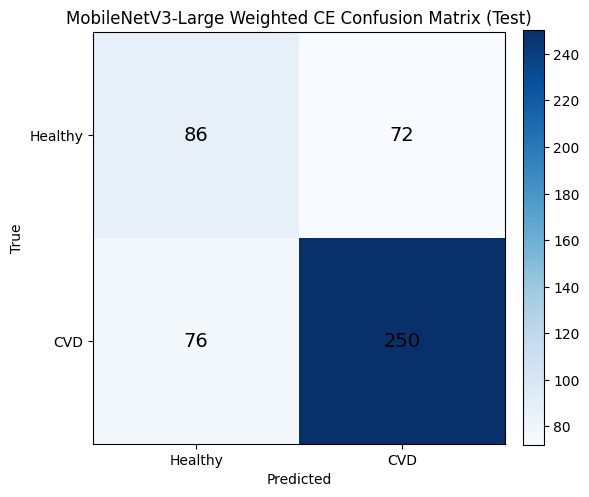

In [ ]:
@torch.no_grad()
def evaluate_test_mnet(X, Y, batch=BATCH_SIZE):
    model.eval()

    N = X.size(0)
    total_loss = 0.0
    logits_all = []

    for i in range(0, N, batch):
        xb = X[i:i+batch]
        yb = Y[i:i+batch]

        with amp_ctx():
            logits = model(xb)
            loss = criterion(logits, yb)

        total_loss += loss.item() * yb.size(0)
        logits_all.append(logits.detach())

    logits_cat = torch.cat(logits_all, dim=0)
    y_true = Y.detach().cpu().numpy()

    mets = metrics_from_logits(logits_cat, y_true)
    mets["loss"] = total_loss / N

    y_pred = logits_cat.argmax(1).detach().cpu().numpy()
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

    return mets, cm, y_pred

# Test
teM_m, cm_m, yhat_m = evaluate_test_mnet(Xte, Yte, batch=BATCH_SIZE)

print("\n=== TEST METRICS: MobileNetV3-Large Weighted CE ===")
print(
    f"  loss={teM_m['loss']:.3f} | acc={teM_m['acc']:.3f} | "
    f"prec={teM_m['prec']:.3f} | rec={teM_m['rec']:.3f} | "
    f"f1={teM_m['f1']:.3f} | auc={teM_m['auc']:.3f} | mcc={teM_m['mcc']:.3f}"
)

print("\nPer-class classification report:")
print(classification_report(Yte.detach().cpu().numpy(), yhat_m, digits=3, zero_division=0))

print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm_m)

# Confusion matrix
try:
    tick_labels = CLASS_NAMES
    assert len(tick_labels) == NUM_CLASSES
except Exception:
    tick_labels = ["Healthy", "CVD"] if NUM_CLASSES == 2 else [str(i) for i in range(NUM_CLASSES)]

plt.figure(figsize=(6, 6))
im = plt.imshow(cm_m, cmap="Blues", interpolation="nearest")
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.title("MobileNetV3-Large Weighted CE Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(NUM_CLASSES), tick_labels)
plt.yticks(range(NUM_CLASSES), tick_labels)

for i in range(cm_m.shape[0]):
    for j in range(cm_m.shape[1]):
        plt.text(j, i, str(cm_m[i, j]), ha="center", va="center", fontsize=14, color="black")

plt.tight_layout()

cm_path_m = OUT_DIR_M / "confusion_matrix_test_weightedCE.png"
plt.savefig(cm_path_m, dpi=200, bbox_inches="tight")

print(f"\n[Saved] Confusion matrix figure -> {cm_path_m}")
plt.show()

## MobileNetV3-Large Fusion Training

In [ ]:
LR_RUN = 1e-4
EPOCHS_RUN = 40
PATIENCE_RUN = 8
WEIGHT_DECAY = 1e-4
STOP_METRIC = "f1"
AUG_P = 0.5

OUT_DIR_MF = Path("runs_mobilenetv3_fusion_lr1e4_ep40_weightedCE")
OUT_DIR_MF.mkdir(exist_ok=True, parents=True)
Path("checkpoints").mkdir(exist_ok=True)

# Model
class FusionMobileNetV3(nn.Module):
    def __init__(self, hf_dim, num_classes=2, p_drop=0.2):
        super().__init__()

        self.backbone = timm.create_model(
            "mobilenetv3_large_100",
            pretrained=True,
            num_classes=0,
            global_pool="avg"
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 3, 224, 224)
            self.feat_dim = self.backbone(dummy).shape[1]

        self.img_proj = nn.Sequential(
            nn.LayerNorm(self.feat_dim),
            nn.Linear(self.feat_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop)
        )

        self.hf_proj = nn.Sequential(
            nn.LayerNorm(hf_dim),
            nn.Linear(hf_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop)
        )

        self.head = nn.Sequential(
            nn.Linear(512 + 256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(512, num_classes)
        )

    def forward(self, x_img, x_hf):
        z = self.img_proj(self.backbone(x_img))
        h = self.hf_proj(x_hf)
        return self.head(torch.cat([z, h], dim=1))

fusion_m = FusionMobileNetV3(hf_dim=HFtr_t.size(1), num_classes=NUM_CLASSES, p_drop=0.2).to(device)

# Freeze backbone
for p in fusion_m.backbone.parameters():
    p.requires_grad = False

# Weighted CE loss
class_counts = torch.bincount(Ytr.detach().cpu(), minlength=NUM_CLASSES).float()
class_weights = (class_counts.sum() / (NUM_CLASSES * class_counts)).to(device)

print("Class counts:", class_counts.tolist())
print("Class weights:", class_weights.detach().cpu().tolist())

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    [
        {"params": fusion_m.img_proj.parameters(), "lr": LR_RUN},
        {"params": fusion_m.hf_proj.parameters(), "lr": LR_RUN},
        {"params": fusion_m.head.parameters(), "lr": LR_RUN},
    ],
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

_device_is_cuda = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda") if _device_is_cuda else None

def amp_ctx():
    return torch.amp.autocast("cuda") if _device_is_cuda else nullcontext()

# Augmentation
def augment_fusion_gpu(x):
    if not fusion_m.training:
        return x

    if torch.rand(1, device=x.device) < AUG_P:
        x = torch.flip(x, dims=[3])

    b = (torch.rand(x.size(0), 1, 1, 1, device=x.device) - 0.5) * 0.10
    c = 1.0 + (torch.rand(x.size(0), 1, 1, 1, device=x.device) - 0.5) * 0.10
    return (x * c + b).clamp_(-4, 4)

# One epoch
def _epoch_mobilenet_fusion(X, HF, Y, train=True, batch=BATCH_SIZE):
    fusion_m.train(train)

    N = X.size(0)
    order = torch.randperm(N, device=device) if train else torch.arange(N, device=device)
    total_loss, logits_all = 0.0, []

    for i in range(0, N, batch):
        idx = order[i:i+batch]
        xb, hb, yb = X[idx], HF[idx], Y[idx]

        if train:
            xb = augment_fusion_gpu(xb)

        with amp_ctx():
            out = fusion_m(xb, hb)
            loss = criterion(out, yb)

        if train:
            optimizer.zero_grad(set_to_none=True)

            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * yb.size(0)
        logits_all.append(out.detach())

    logits = torch.cat(logits_all, dim=0)
    mets = metrics_from_logits(logits, Y.detach().cpu().numpy())
    mets["loss"] = total_loss / N
    return mets

# Training
best_score = -1.0
best_state = None
best_epoch = -1
best_val = None
best_train = None
pat = PATIENCE_RUN
history = []

for ep in range(1, EPOCHS_RUN + 1):
    trM = _epoch_mobilenet_fusion(Xtr, HFtr_t, Ytr, train=True, batch=BATCH_SIZE)
    vaM = _epoch_mobilenet_fusion(Xva, HFva_t, Yva, train=False, batch=BATCH_SIZE)

    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": ep, "lr": current_lr,
        "tr_loss": trM["loss"], "tr_acc": trM["acc"], "tr_prec": trM["prec"],
        "tr_rec": trM["rec"], "tr_f1": trM["f1"], "tr_auc": trM["auc"], "tr_mcc": trM["mcc"],
        "va_loss": vaM["loss"], "va_acc": vaM["acc"], "va_prec": vaM["prec"],
        "va_rec": vaM["rec"], "va_f1": vaM["f1"], "va_auc": vaM["auc"], "va_mcc": vaM["mcc"]
    })

    print(
        f"[Ep {ep:02d}] LR={current_lr:.2e} | "
        f"TR L={trM['loss']:.3f} A={trM['acc']:.3f} F1={trM['f1']:.3f} AUC={trM['auc']:.3f} | "
        f"VA L={vaM['loss']:.3f} A={vaM['acc']:.3f} F1={vaM['f1']:.3f} AUC={vaM['auc']:.3f}"
    )

    scheduler.step(vaM[STOP_METRIC])
    score = vaM[STOP_METRIC]

    if score > best_score:
        best_score = score
        best_state = {k: v.detach().cpu() for k, v in fusion_m.state_dict().items()}
        best_epoch = ep
        best_val = vaM.copy()
        best_train = trM.copy()
        pat = PATIENCE_RUN
    else:
        pat -= 1
        if pat <= 0:
            print("Early stop.")
            break

# Best checkpoint
ckpt_path_mf = "checkpoints/mobilenetv3_fusion_best_lr1e4_ep40_weightedCE.pth"

if best_state is not None:
    torch.save(best_state, ckpt_path_mf)
    fusion_m.load_state_dict(best_state, strict=True)

# Training history
log_df = pd.DataFrame(history)
csv_path_mf = OUT_DIR_MF / "train_val_metrics.csv"

try:
    log_df.to_csv(csv_path_mf, index=False)
except PermissionError:
    csv_path_mf = OUT_DIR_MF / f"train_val_metrics_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    log_df.to_csv(csv_path_mf, index=False)

print(f"\n=== Best FusionMobileNetV3 checkpoint by val {STOP_METRIC.upper()} at epoch {best_epoch} ===")

print("VAL:")
print(
    f"  loss={best_val['loss']:.3f} | acc={best_val['acc']:.3f} | "
    f"prec={best_val['prec']:.3f} | rec={best_val['rec']:.3f} | "
    f"f1={best_val['f1']:.3f} | auc={best_val['auc']:.3f} | mcc={best_val['mcc']:.3f}"
)

print("TRAIN:")
print(
    f"  loss={best_train['loss']:.3f} | acc={best_train['acc']:.3f} | "
    f"prec={best_train['prec']:.3f} | rec={best_train['rec']:.3f} | "
    f"f1={best_train['f1']:.3f} | auc={best_train['auc']:.3f} | mcc={best_train['mcc']:.3f}"
)

print(f"\nCheckpoint saved to: {ckpt_path_mf}")
print(f"History CSV saved to: {csv_path_mf}")

# Validation threshold tuning
@torch.no_grad()
def _val_probs_mobilenet_fusion(X, HF, batch=BATCH_SIZE):
    fusion_m.eval()
    probs = []

    for i in range(0, X.size(0), batch):
        xb, hb = X[i:i+batch], HF[i:i+batch]

        with amp_ctx():
            logits = fusion_m(xb, hb)

        probs.append(torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy())

    return np.concatenate(probs, axis=0)

va_prob = _val_probs_mobilenet_fusion(Xva, HFva_t, batch=BATCH_SIZE)
yva_np = Yva.detach().cpu().numpy()

ths = np.linspace(0.2, 0.8, 61)
best_thr = 0.5
best_f1_tune = -1.0

for t in ths:
    pred = (va_prob >= t).astype(int)
    _, _, f1_t, _ = precision_recall_fscore_support(yva_np, pred, average="macro", zero_division=0)

    if f1_t > best_f1_tune:
        best_f1_tune = f1_t
        best_thr = t

THRESHOLD_MF = float(best_thr)

print(f"[Threshold] Selected τ*={THRESHOLD_MF:.3f} using VAL macro-F1={best_f1_tune:.3f}")

Class counts: [567.0, 1369.0]
Class weights: [1.707231044769287, 0.7070854902267456]
[Ep 01] LR=1.00e-04 | TR L=0.621 A=0.524 F1=0.483 AUC=0.477 | VA L=0.562 A=0.776 F1=0.709 AUC=0.785
[Ep 02] LR=1.00e-04 | TR L=0.550 A=0.552 F1=0.498 AUC=0.497 | VA L=0.518 A=0.789 F1=0.741 AUC=0.825
[Ep 03] LR=1.00e-04 | TR L=0.513 A=0.536 F1=0.478 AUC=0.467 | VA L=0.531 A=0.749 F1=0.700 AUC=0.809
[Ep 04] LR=1.00e-04 | TR L=0.482 A=0.547 F1=0.490 AUC=0.503 | VA L=0.543 A=0.731 F1=0.693 AUC=0.805
[Ep 05] LR=1.00e-04 | TR L=0.445 A=0.552 F1=0.499 AUC=0.495 | VA L=0.562 A=0.737 F1=0.694 AUC=0.794
[Ep 06] LR=5.00e-05 | TR L=0.414 A=0.588 F1=0.533 AUC=0.543 | VA L=0.562 A=0.762 F1=0.706 AUC=0.792
[Ep 07] LR=5.00e-05 | TR L=0.376 A=0.550 F1=0.490 AUC=0.488 | VA L=0.575 A=0.756 F1=0.705 AUC=0.788
[Ep 08] LR=5.00e-05 | TR L=0.354 A=0.539 F1=0.475 AUC=0.463 | VA L=0.594 A=0.764 F1=0.707 AUC=0.779
[Ep 09] LR=2.50e-05 | TR L=0.319 A=0.550 F1=0.484 AUC=0.482 | VA L=0.616 A=0.768 F1=0.707 AUC=0.778
[Ep 10] LR=2.50

## MobileNetV3-Large Fusion Test Evaluation


=== TEST METRICS: MobileNetV3-Large Fusion @ τ* ===
  acc=0.729 | prec=0.691 | rec=0.685 | f1=0.688 | auc=0.766 | mcc=0.376

Per-class TEST report:
              precision    recall  f1-score   support

           0      0.591     0.557     0.573       158
           1      0.791     0.813     0.802       326

    accuracy                          0.729       484
   macro avg      0.691     0.685     0.688       484
weighted avg      0.726     0.729     0.727       484


Confusion Matrix (rows=true, cols=pred):
[[ 88  70]
 [ 61 265]]

[Saved] Confusion matrix figure -> runs_mobilenetv3_fusion_lr1e4_ep40_weightedCE\confusion_matrix_test_fusion_thr.png


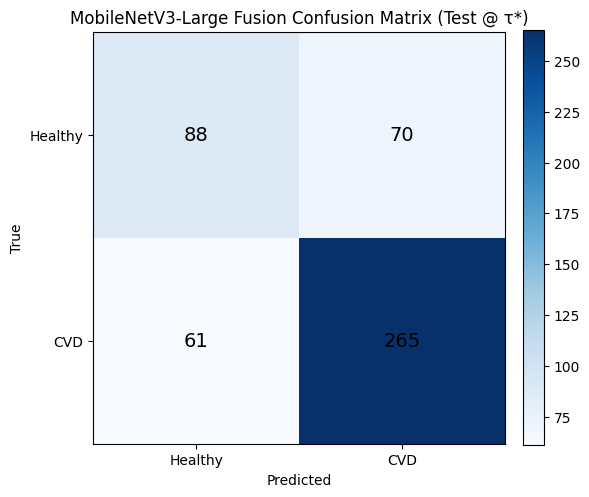

In [ ]:
@torch.no_grad()
def _test_probs_logits_mobilenet_fusion(X, HF, batch=BATCH_SIZE):
    fusion_m.eval()
    probs, logits_all = [], []

    for i in range(0, X.size(0), batch):
        xb = X[i:i+batch]
        hb = HF[i:i+batch]

        with amp_ctx():
            logits = fusion_m(xb, hb)

        probs.append(torch.softmax(logits, dim=1)[:, 1].detach().cpu())
        logits_all.append(logits.detach().cpu())

    return torch.cat(probs).numpy(), torch.cat(logits_all)

# Test
te_prob_mf, te_logits_mf = _test_probs_logits_mobilenet_fusion(Xte, HFte_t, batch=BATCH_SIZE)

yte_np = Yte.detach().cpu().numpy()
yhat_mf = (te_prob_mf >= THRESHOLD_MF).astype(int)

acc = accuracy_score(yte_np, yhat_mf)
prec, rec, f1, _ = precision_recall_fscore_support(yte_np, yhat_mf, average="macro", zero_division=0)
auc = roc_auc_score(yte_np, te_prob_mf)
mcc = matthews_corrcoef(yte_np, yhat_mf)
cm = confusion_matrix(yte_np, yhat_mf, labels=list(range(NUM_CLASSES)))

print("\n=== TEST METRICS: MobileNetV3-Large Fusion @ τ* ===")
print(
    f"  acc={acc:.3f} | prec={prec:.3f} | rec={rec:.3f} | "
    f"f1={f1:.3f} | auc={auc:.3f} | mcc={mcc:.3f}"
)

print("\nPer-class TEST report:")
print(classification_report(yte_np, yhat_mf, digits=3, zero_division=0))

print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm)

# Confusion matrix
try:
    tick_labels = CLASS_NAMES
    assert len(tick_labels) == NUM_CLASSES
except Exception:
    tick_labels = ["Healthy", "CVD"] if NUM_CLASSES == 2 else [str(i) for i in range(NUM_CLASSES)]

plt.figure(figsize=(6, 6))
im = plt.imshow(cm, cmap="Blues", interpolation="nearest")
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.title("MobileNetV3-Large Fusion Confusion Matrix (Test @ τ*)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(NUM_CLASSES), tick_labels)
plt.yticks(range(NUM_CLASSES), tick_labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14, color="black")

plt.tight_layout()

cm_path_mf = OUT_DIR_MF / "confusion_matrix_test_fusion_thr.png"
plt.savefig(cm_path_mf, dpi=200, bbox_inches="tight")

print(f"\n[Saved] Confusion matrix figure -> {cm_path_mf}")
plt.show()